<a href="https://colab.research.google.com/github/dibaaminshahidi/ED-HGNN-ICU-LoS/blob/main/Read_BigQuery_Make_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.cloud import bigquery
import pandas as pd
import polars as pl
import plotly.express as px
import os
import gc
import numpy as np
from google.colab import drive
from google.colab import auth
import re

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir = '/content/drive/MyDrive/Thesis/Codes/Data'
save_file_address = f'Tables_24'
os.makedirs(f'{dir}/{save_file_address}', exist_ok=True)

# Generate CSV with Query

## Set Up

In [ ]:
def process_query_in_chunks(query, output_dir, output_filename, drive_dir = dir, page_size=1_000_000):
    job = client.query(query)
    result = job.result(page_size=page_size)
    schema_fields = {field.name: field.field_type for field in result.schema}

    os.makedirs(output_dir, exist_ok=True)

    chunk_id = 0
    global_schema = None
    temp_chunk_files = []
    for page in result.pages:
        print(f"Processing chunk {chunk_id}...")
        rows = [dict(row.items()) for row in page]
        if not rows:
            print(f"No rows in chunk {chunk_id}. Skipping...")
            continue

        pdf = pd.DataFrame(rows)

        for col, bq_type in schema_fields.items():
            if col not in pdf.columns:
                continue
            if bq_type in ("STRING", "DATE", "DATETIME", "TIMESTAMP"):
                pdf[col] = pdf[col].astype("string")
            elif bq_type in ("INTEGER", "INT64"):
                pdf[col] = pd.to_numeric(pdf[col], errors="coerce").astype("Int64")
            elif bq_type in ("FLOAT", "FLOAT64", "NUMERIC", "BIGNUMERIC"):
                pdf[col] = pd.to_numeric(pdf[col], errors="coerce").astype("float64")
            elif bq_type in ("BOOLEAN", "BOOL"):
                pdf[col] = pdf[col].astype("boolean")

        try:
            pl_df = pl.from_pandas(pdf, include_index=False)
        except Exception as e:
            print(f"Could not convert to Polars DataFrame: {e}")
            continue

        if global_schema is None:
            global_schema = pl_df.schema
        else:
            try:
                pl_df = pl_df.cast(global_schema)
            except Exception as e:
                print(f"Schema casting failed in chunk {chunk_id}: {e}")
                continue

        chunk_file_path = f"{output_dir}/chunk_{output_filename}_{chunk_id}.parquet"
        pl_df.write_parquet(chunk_file_path, compression="zstd")
        temp_chunk_files.append(chunk_file_path)

        del pdf, pl_df
        gc.collect()
        chunk_id += 1

    if not temp_chunk_files:
        print("No chunks were successfully processed.")
        return

    print("Combining all chunks...")
    try:
        all_chunks = pl.scan_parquet(temp_chunk_files)
    except Exception as e:
        print(f"Failed to scan combined chunks: {e}")
        return

    drive_dir = f'{dir}/{output_dir}'
    os.makedirs(drive_dir, exist_ok=True)
    final_output_path = os.path.join(drive_dir, output_filename + '.parquet')

    print(f"Saving combined Parquet to: {final_output_path}")
    all_chunks.sink_parquet(final_output_path)

    print("Process completed successfully.")


In [ ]:
auth.authenticate_user()

project_id = input('gpc projec id: ')
client = bigquery.Client(project= project_id)

#thesis-462417-470712

gpc projec id: thesis-462417-470712


## Stay


### Make

#### Choose Scores

Should Be Used in Chapter 3

In [ ]:
icu_stay = """
SELECT
  icu.subject_id,
  icu.hadm_id,
  icu.stay_id,
  first_careunit as icu_careunit,
  IF(edregtime IS NOT NULL,1 , 0) as er_register,
  admission_type as hosp_admission_type,
  admission_location as hosp_admission_location,
  DATETIME_DIFF(intime, admiss.admittime, MINUTE)/60/24 as icu_admission_to_hosp_admission,
  COALESCE(DATETIME_DIFF(intime, edregtime, MINUTE)/60/24, 0) as icu_admission_to_er_admission,
  los
FROM `physionet-data.mimiciv_3_1_icu.icustays` as icu
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` as admiss
  USING(hadm_id)
WHERE DATETIME_DIFF(intime, admiss.admittime, MINUTE)  >= 0
      AND los IS NOT NULL
"""

process_query_in_chunks(icu_stay, save_file_address, 'icu_stay')

In [ ]:
icu_stay_full_scores = """
  SELECT
  icu.subject_id,
  icu.hadm_id,
  icu.stay_id,
  first_careunit as icu_careunit,
  IF(edregtime IS NOT NULL,1 , 0) as er_register,

  admission_type as hosp_admission_type,
  admission_location as hosp_admission_location,

  DATETIME_DIFF(intime, admiss.admittime, MINUTE)/60/24 as icu_admission_to_hosp_admission,
  COALESCE(DATETIME_DIFF(intime, edregtime, MINUTE)/60/24, 0) as icu_admission_to_er_admission,

  lods.lods as lods,
  lods.neurologic as lods_neurologic,
  lods.hematologic as lods_hematologic,
  lods.cardiovascular as lods_cardiovascular,
  lods.renal as lods_renal,
  lods.pulmonary as lods_pulmonary,
  lods.hematologic as lods_hematologic,
  lods.hepatic as lods_hepatic,
  sofa.sofa as sofa,
  sofa.respiration as sofa_respiration,
  sofa.coagulation as sofa_coagulation,
  sofa.liver as sofa_liver,
  sofa.cardiovascular as sofa_cardiovascular,
  sofa.cns as sofa_cns,
  sofa.renal as sofa_renal,
  meld.meld_initial as meld_initial,
  meld.meld as meld,
  meld.rrt as meld_rrt,
  meld.creatinine_max as meld_creatinine_max,
  meld.bilirubin_total_max as meld_bilirubin_total_max,
  meld.inr_max as meld_inr_max,
  meld.sodium_min as meld_sodium_min,
  apsiii.apsiii as apsiii,
  apsiii.apsiii_prob as apsiii_prob,
  apsiii.hr_score as apsiii_hr_score,
  apsiii.mbp_score as apsiii_mbp_score,
  apsiii.temp_score as apsiii_temp_score,
  apsiii.resp_rate_score as apsiii_resp_rate_score,
  apsiii.pao2_aado2_score as apsiii_pao2_aado2_score,
  apsiii.hematocrit_score as apsiii_hematocrit_score,
  apsiii.wbc_score as apsiii_wbc_score,
  apsiii.creatinine_score as apsiii_creatinine_score,
  apsiii.uo_score as apsiii_uo_score,
  apsiii.bun_score as apsiii_bun_score,
  apsiii.sodium_score as apsiii_sodium_score,
  apsiii.albumin_score as apsiii_albumin_score,
  apsiii.bilirubin_score as apsiii_bilirubin_score,
  apsiii.glucose_score as apsiii_glucose_score,
  apsiii.acidbase_score as apsiii_acidbase_score,
  apsiii.gcs_score as apsiii_gcs_score,
  oasis.oasis as oasis,
  oasis.oasis_prob as oasis_prob,
  oasis.age as oasis_age,
  oasis.age_score as oasis_age_score,
  oasis.preiculos as oasis_preiculos,
  oasis.preiculos_score as oasis_preiculos_score,
  oasis.gcs as oasis_gcs,
  oasis.gcs_score as oasis_gcs_score,
  oasis.heartrate as oasis_heartrate,
  oasis.heart_rate_score as oasis_heart_rate_score,
  oasis.meanbp as oasis_meanbp,
  oasis.mbp_score as oasis_mbp_score,
  oasis.resprate as oasis_resprate,
  oasis.resp_rate_score as oasis_resp_rate_score,
  oasis.`temp` as oasis_temp,
  oasis.temp_score as oasis_temp_score,
  oasis.urineoutput as oasis_urineoutput,
  oasis.urineoutput_score as oasis_urineoutput_score,
  oasis.mechvent as oasis_mechvent,
  oasis.mechvent_score as oasis_mechvent_score,
  oasis.electivesurgery as oasis_electivesurgery,
  oasis.electivesurgery_score as oasis_electivesurgery_score,
  los,
  FROM `physionet-data.mimiciv_3_1_icu.icustays` as icu
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.lods` as lods
  USING(stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.meld` as meld
  USING(stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.first_day_sofa` as sofa
  USING(stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.apsiii` as apsiii
  USING(stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis` as oasis
  USING(stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` as admiss
  ON icu.hadm_id = admiss.hadm_id
  WHERE DATETIME_DIFF(intime, admiss.admittime, MINUTE)  >= 0
        AND los IS NOT NULL

"""

process_query_in_chunks(icu_stay_full_scores, save_file_address, 'icu_stay_full_score')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance


def safe_log1p(x):
    x = np.asarray(x)
    x = np.clip(x, 0, None)
    return np.log1p(x)

df = df.copy()
df = df[df["los"].notna() & (df["los"] >= 0)].copy()
df["y_log"] = safe_log1p(df["los"])

BASE_CAT = ["icu_careunit", "hosp_admission_type", "hosp_admission_location"]
BASE_NUM = ["er_register", "icu_admission_to_hosp_admission", "icu_admission_to_er_admission"]

SCORES = ["apsiii", "oasis", "sofa", "lods", "meld", "meld_initial"]

APS_COMP = [c for c in df.columns if c.startswith("apsiii_") and c not in ["apsiii", "apsiii_prob"]]
OAS_COMP = [c for c in df.columns if c.startswith("oasis_") and c not in ["oasis", "oasis_prob"]]
SOFA_COMP = [c for c in df.columns if c.startswith("sofa_") and c != "sofa"]
LODS_COMP = [c for c in df.columns if c.startswith("lods_") and c != "lods"]
MELD_COMP = [c for c in df.columns if c.startswith("meld_") and c not in ["meld", "meld_initial"]]

SCORES = [c for c in SCORES if c in df.columns]

GROUP_COL = "subject_id"
TARGET = "y_log"


def missing_report(cols, title="Missingness report", top_n=50):
    cols = [c for c in cols if c in df.columns]
    rep = pd.DataFrame({
        "col": cols,
        "non_null": [df[c].notna().sum() for c in cols],
        "missing": [df[c].isna().sum() for c in cols],
        "missing_pct": [df[c].isna().mean() * 100 for c in cols],
    }).sort_values("missing_pct", ascending=False)

    print(f"\n=== {title} ===")
    print(rep.head(top_n).to_string(index=False))

    # Plot
    d = rep.head(top_n).iloc[::-1]
    fig = plt.figure(figsize=(10, max(4, 0.25 * len(d))))
    ax = fig.add_subplot(1, 1, 1)
    ax.barh(d["col"], d["missing_pct"])
    ax.set_title(f"{title} (Top {top_n} by missing %)")
    ax.set_xlabel("Missing %")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
    return rep

miss_scores = missing_report(SCORES, "Scores missingness", top_n=30)
miss_aps = missing_report(APS_COMP, "APSIII components missingness", top_n=50)
miss_oas = missing_report(OAS_COMP, "OASIS components missingness", top_n=50)
miss_sof = missing_report(SOFA_COMP, "SOFA components missingness", top_n=50)
miss_lod = missing_report(LODS_COMP, "LODS components missingness", top_n=50)
miss_mel = missing_report(MELD_COMP, "MELD components missingness", top_n=50)

def corr_heatmap(cols, method="spearman", title="Correlation heatmap"):
    cols = [c for c in cols if c in df.columns]
    d = df[cols].copy()
    corr = d.corr(method=method)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(1, 1, 1)
    im = ax.imshow(corr.values, aspect="auto")
    ax.set_title(f"{title} ({method})")
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticklabels(cols)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()
    return corr

score_corr = corr_heatmap(SCORES, method="spearman", title="Scores redundancy")


def spearman_with_target(cols, target=TARGET, min_n=1000):
    rows = []
    for c in cols:
        if c not in df.columns:
            continue
        tmp = df[[c, target]].dropna()
        if len(tmp) < min_n:
            continue
        rho = tmp[c].corr(tmp[target], method="spearman")
        rows.append((c, float(rho), len(tmp), df[c].isna().mean()*100))
    out = pd.DataFrame(rows, columns=["feature", "spearman_rho", "n", "missing_pct"]).sort_values("spearman_rho", ascending=False)
    return out

def mutual_info_with_target(cols, target=TARGET, min_n=5000, random_state=42):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    y = df[target].copy()

    keep = []
    for c in cols:
        tmp = df[[c, target]].dropna()
        if len(tmp) >= min_n:
            keep.append(c)
    cols = keep
    if not cols:
        return pd.DataFrame(columns=["feature", "mi", "n", "missing_pct"])

    X = df[cols].copy()
    y = df[target].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True))

    mi = mutual_info_regression(X.values, y.values, random_state=random_state)
    out = pd.DataFrame({
        "feature": cols,
        "mi": mi,
        "n": len(df),
        "missing_pct": [df[c].isna().mean()*100 for c in cols],
    }).sort_values("mi", ascending=False)
    return out

score_rho = spearman_with_target(SCORES, min_n=10000)
print("\n=== Scores Spearman vs log1p(LOS) ===")
print(score_rho.to_string(index=False))

score_mi = mutual_info_with_target(SCORES, min_n=20000)
print("\n=== Scores Mutual Information vs log1p(LOS) ===")
print(score_mi.to_string(index=False))

for name, cols in [
    ("APS components", APS_COMP),
    ("OASIS components", OAS_COMP),
    ("SOFA components", SOFA_COMP),
    ("LODS components", LODS_COMP),
    ("MELD components", MELD_COMP),
]:
    cols = [c for c in cols if c in df.columns]
    if not cols:
        continue
    rho = spearman_with_target(cols, min_n=5000).head(30)
    print(f"\n=== Top components by Spearman: {name} ===")
    print(rho.to_string(index=False))


def make_model(cat_cols, num_cols):
    cat_cols = [c for c in cat_cols if c in df.columns]
    num_cols = [c for c in num_cols if c in df.columns]

    pre = ColumnTransformer(
        transformers=[
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler())
            ]), num_cols),
        ],
        remainder="drop"
    )
    model = Ridge(alpha=3.0, random_state=42)
    return Pipeline([("pre", pre), ("model", model)])

def eval_feature_set(name, cat_cols, num_cols, target=TARGET, groups_col=GROUP_COL, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    X = df[cat_cols + num_cols].copy()
    y = df[target].values
    groups = df[groups_col].values

    pipe = make_model(cat_cols, num_cols)

    maes = []
    rmses = []
    r2s = []

    for tr, te in gkf.split(X, y, groups):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)

        maes.append(mean_absolute_error(yte, pred))
        rmses.append(np.sqrt(mean_squared_error(yte, pred)))
        r2s.append(r2_score(yte, pred))

    out = {
        "set": name,
        "mae_log": float(np.mean(maes)),
        "rmse_log": float(np.mean(rmses)),
        "r2_log": float(np.mean(r2s)),
        "mae_log_std": float(np.std(maes)),
        "n": len(df),
    }
    return out

SETS = []

SETS.append(("Base", BASE_CAT, BASE_NUM))

SETS.append(("Base + OASIS", BASE_CAT, BASE_NUM + ["oasis"]))

SETS.append(("Base + SOFA", BASE_CAT, BASE_NUM + ["sofa"]))

SETS.append(("Base + OASIS + SOFA", BASE_CAT, BASE_NUM + ["oasis", "sofa"]))

if "apsiii" in df.columns:
    SETS.append(("Base + APSIII", BASE_CAT, BASE_NUM + ["apsiii"]))

if "apsiii" in df.columns:
    SETS.append(("Base + APSIII + SOFA", BASE_CAT, BASE_NUM + ["apsiii", "sofa"]))

if "lods" in df.columns:
    SETS.append(("Base + LODS", BASE_CAT, BASE_NUM + ["lods"]))
if "meld" in df.columns:
    SETS.append(("Base + MELD", BASE_CAT, BASE_NUM + ["meld"]))

results = []
for name, cats, nums in SETS:
    nums = [c for c in nums if c in df.columns]
    results.append(eval_feature_set(name, cats, nums))

res_df = pd.DataFrame(results).sort_values("mae_log")
print("\n=== Ablation (GroupKFold) - lower MAE is better ===")
print(res_df.to_string(index=False))

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.bar(res_df["set"], res_df["mae_log"])
ax.set_title("Ablation: MAE on log1p(LOS) (GroupKFold)")
ax.set_ylabel("MAE (log1p days)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


def permutation_importance_on_best(best_set_name, cat_cols, num_cols, n_repeats=5):
    gkf = GroupKFold(n_splits=5)
    X = df[cat_cols + num_cols].copy()
    y = df[TARGET].values
    groups = df[GROUP_COL].values
    tr, te = next(gkf.split(X, y, groups))

    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr, yte = y[tr], y[te]

    pipe = make_model(cat_cols, num_cols)
    pipe.fit(Xtr, ytr)

    r = permutation_importance(
        pipe, Xte, yte,
        n_repeats=n_repeats,
        random_state=42,
        scoring="neg_mean_absolute_error"
    )
    out = pd.DataFrame({
        "feature": X.columns,
        "importance": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance", ascending=False)

    print(f"\n=== Permutation importance (raw columns) for: {best_set_name} ===")
    print(out.head(30).to_string(index=False))

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1)
    top = out.head(20).iloc[::-1]
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"Permutation Importance (Top 20) - {best_set_name}")
    ax.set_xlabel("Importance (Δ MAE, higher = more important)")
    plt.tight_layout()
    plt.show()

    return out

best_row = res_df.iloc[0]
best_name = best_row["set"]
best_set = [s for s in SETS if s[0] == best_name][0]
_ = permutation_importance_on_best(best_name, best_set[1], best_set[2], n_repeats=3)


def decide_drop_candidates(feature_list, min_nonnull_frac=0.7, min_abs_rho=0.03):
    """
    min_nonnull_frac: حداقل درصد داده‌ی موجود (مثلاً 0.7 یعنی حداقل 70% non-null)
    min_abs_rho: حداقل |spearman| با log(LOS) برای اینکه ارزش داشته باشد
    """
    cols = [c for c in feature_list if c in df.columns]
    out = []
    for c in cols:
        nn_frac = df[c].notna().mean()
        tmp = df[[c, TARGET]].dropna()
        rho = tmp[c].corr(tmp[TARGET], method="spearman") if len(tmp) > 2000 else np.nan
        out.append((c, nn_frac, rho))
    d = pd.DataFrame(out, columns=["feature", "nonnull_frac", "spearman_rho"]).dropna()
    d["abs_rho"] = d["spearman_rho"].abs()
    drop = d[(d["nonnull_frac"] < min_nonnull_frac) & (d["abs_rho"] < min_abs_rho)].sort_values(["nonnull_frac", "abs_rho"])
    keep = d.drop(drop.index).sort_values("abs_rho", ascending=False)
    return keep, drop

keep_aps, drop_aps = decide_drop_candidates(APS_COMP, min_nonnull_frac=0.7, min_abs_rho=0.03)
print("\n=== APSIII components: DROP candidates (missing high + signal low) ===")
print(drop_aps.head(50).to_string(index=False))

keep_sofa, drop_sofa = decide_drop_candidates(SOFA_COMP, min_nonnull_frac=0.7, min_abs_rho=0.03)
print("\n=== SOFA components: DROP candidates (missing high + signal low) ===")
print(drop_sofa.head(50).to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = df.copy()
df = df[df["los"].notna() & (df["los"] >= 0)].copy()
df["y_log"] = np.log1p(df["los"].clip(lower=0))

GROUP_COL = "subject_id"
TARGET = "y_log"

drop_prefixes = ["apsiii_", "lods_", "meld_"]
drop_exact = ["apsiii", "apsiii_prob", "lods", "meld", "meld_initial"]

drop_cols = set()
for c in df.columns:
    if any(c.startswith(p) for p in drop_prefixes):
        drop_cols.add(c)
for c in drop_exact:
    if c in df.columns:
        drop_cols.add(c)

df_pruned = df.drop(columns=sorted(drop_cols), errors="ignore").copy()

print(f"Dropped {len(drop_cols)} columns.")
print("Remaining columns:", len(df_pruned.columns))


BASE_CAT = ["icu_careunit", "hosp_admission_type", "hosp_admission_location"]
BASE_NUM = ["er_register", "icu_admission_to_hosp_admission", "icu_admission_to_er_admission"]


KEEP_SCORES = ["oasis", "sofa"]

OPTIONAL_ADD = ["oasis_mechvent"]

def existing(cols):
    return [c for c in cols if c in df_pruned.columns]

BASE_CAT = existing(BASE_CAT)
BASE_NUM = existing(BASE_NUM)

SETS = [
    ("Base + OASIS + SOFA", BASE_CAT, existing(BASE_NUM + ["oasis", "sofa"])),
    ("Base + OASIS",        BASE_CAT, existing(BASE_NUM + ["oasis"])),
    ("Base + SOFA",         BASE_CAT, existing(BASE_NUM + ["sofa"])),
    ("Base + OASIS + SOFA + mechvent", BASE_CAT, existing(BASE_NUM + ["oasis", "sofa"] + OPTIONAL_ADD)),
]

SETS = [(n, c, x) for (n, c, x) in SETS if len(x) > 0]

print("\nFeature sets:")
for n, c, x in SETS:
    print(f"- {n}: cat={len(c)}, num={len(x)}")

def make_model(cat_cols, num_cols):
    pre = ColumnTransformer(
        transformers=[
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler()),
            ]), num_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )
    model = Ridge(alpha=3.0, random_state=42)
    return Pipeline([("pre", pre), ("model", model)])

def eval_set(df_use, set_name, cat_cols, num_cols, seeds=(42, 43, 44), n_splits=5):
    """
    Evaluate MAE/RMSE/R2 on log1p(LOS) with patient-level GroupKFold.
    Seeds are used only for model randomness (Ridge has none) and for any tie-breaking later.
    Kept for consistency if you swap the model later.
    """
    X = df_use[cat_cols + num_cols].copy()
    y = df_use[TARGET].values
    groups = df_use[GROUP_COL].values

    rows = []
    for seed in seeds:
        gkf = GroupKFold(n_splits=n_splits)
        maes, rmses, r2s = [], [], []
        for tr, te in gkf.split(X, y, groups):
            pipe = make_model(cat_cols, num_cols)
            pipe.fit(X.iloc[tr], y[tr])
            pred = pipe.predict(X.iloc[te])

            maes.append(mean_absolute_error(y[te], pred))
            rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
            r2s.append(r2_score(y[te], pred))

        rows.append({
            "set": set_name,
            "seed": seed,
            "mae_log": float(np.mean(maes)),
            "rmse_log": float(np.mean(rmses)),
            "r2_log": float(np.mean(r2s)),
            "mae_log_std_over_folds": float(np.std(maes)),
        })

    out = pd.DataFrame(rows)
    summary = out.groupby("set").agg(
        mae_log_mean=("mae_log", "mean"),
        mae_log_std=("mae_log", "std"),
        rmse_log_mean=("rmse_log", "mean"),
        r2_log_mean=("r2_log", "mean"),
    ).reset_index()

    return out, summary

all_runs = []
summaries = []

for name, cats, nums in SETS:
    runs, summ = eval_set(df_pruned, name, cats, nums)
    all_runs.append(runs)
    summaries.append(summ)

runs_df = pd.concat(all_runs, ignore_index=True)
summary_df = pd.concat(summaries, ignore_index=True).sort_values("mae_log_mean")

print("\n=== Quick decision test (lower MAE is better) ===")
print(summary_df.to_string(index=False))

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.bar(summary_df["set"], summary_df["mae_log_mean"])
ax.set_title("Quick decision test: MAE on log1p(LOS) (GroupKFold, avg over seeds)")
ax.set_ylabel("MAE (log1p days)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

print("\nPer-seed runs:")
print(runs_df.sort_values(["set", "seed"]).to_string(index=False))

best = summary_df.iloc[0]
print(f"\nBest set: {best['set']} | MAE={best['mae_log_mean']:.6f} ± {best['mae_log_std']:.6f} (over seeds)")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df2 = df_pruned.copy()

df2 = df2[df2["los"].notna() & (df2["los"] >= 0)].copy()
df2["y_log"] = np.log1p(df2["los"])

GROUP_COL = "subject_id"
TARGET = "y_log"

BASE_CAT = ["icu_careunit", "hosp_admission_type", "hosp_admission_location"]
BASE_NUM = ["er_register", "icu_admission_to_hosp_admission", "icu_admission_to_er_admission"]

def existing(cols):
    return [c for c in cols if c in df2.columns]

BASE_CAT = existing(BASE_CAT)
BASE_NUM = existing(BASE_NUM)

SETS = [
    ("Base + SOFA + mechvent",
     BASE_CAT,
     existing(BASE_NUM + ["sofa", "oasis_mechvent"])),

    ("Base + OASIS + SOFA + mechvent",
     BASE_CAT,
     existing(BASE_NUM + ["oasis", "sofa", "oasis_mechvent"]))
]

def make_model(cat_cols, num_cols):
    pre = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),

        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols)
    ])

    return Pipeline([
        ("pre", pre),
        ("model", Ridge(alpha=3.0))
    ])

def eval_set(name, cat_cols, num_cols, seeds=(42,43,44)):
    X = df2[cat_cols + num_cols]
    y = df2[TARGET].values
    groups = df2[GROUP_COL].values

    maes = []

    for seed in seeds:
        gkf = GroupKFold(n_splits=5)

        fold_mae = []

        for tr, te in gkf.split(X, y, groups):
            pipe = make_model(cat_cols, num_cols)
            pipe.fit(X.iloc[tr], y[tr])
            pred = pipe.predict(X.iloc[te])

            fold_mae.append(mean_absolute_error(y[te], pred))

        maes.append(np.mean(fold_mae))

    return np.mean(maes), np.std(maes)

results = []

for name, cats, nums in SETS:
    mae_mean, mae_std = eval_set(name, cats, nums)
    results.append((name, mae_mean, mae_std))

res_df = pd.DataFrame(results, columns=["set","mae_mean","mae_std"])
res_df = res_df.sort_values("mae_mean")

print("\n=== Decisive OASIS redundancy test ===")
print(res_df)

plt.figure(figsize=(6,3))
plt.bar(res_df["set"], res_df["mae_mean"])
plt.ylabel("MAE (log1p LOS)")
plt.title("OASIS necessity test")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

#### Selected Scores


In [ ]:
icu_stay_selected_score_query = """
  SELECT
    icu.subject_id,
    icu.hadm_id,
    icu.stay_id,

    icu.first_careunit AS icu_careunit,
    IF(adm.edregtime IS NOT NULL, 1, 0) AS er_register,

    adm.admission_type      AS hosp_admission_type,
    adm.admission_location  AS hosp_admission_location,

    DATETIME_DIFF(icu.intime, adm.admittime, MINUTE) /  60 / 24 AS icu_admission_to_hosp_admission,
    COALESCE(DATETIME_DIFF(icu.intime, adm.edregtime, MINUTE) / 60 / 24, 0) AS icu_admission_to_er_admission,

    sofa.sofa AS sofa,

    oasis.mechvent AS oasis_mechvent,

    icu.los

    FROM `physionet-data.mimiciv_3_1_icu.icustays` AS icu
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.first_day_sofa` AS sofa
      USING (stay_id)
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis` AS oasis
      USING (stay_id)
    LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` AS adm
      ON icu.hadm_id = adm.hadm_id

    WHERE los IS NOT NULL

  ;"""

process_query_in_chunks(icu_stay_selected_score_query, save_file_address, 'icu_stay_selected_score')

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Combining all chunks...
Saving combined Parquet to: /content/drive/MyDrive/Thesis/Codes/Data/Tables_24/icu_stay_selected_score.parquet
Process completed successfully.


### Add Weight

In [ ]:
icu_stay_selected_score = pd.read_parquet(f'{dir}/{save_file_address}/icu_stay_selected_score.parquet')

In [ ]:
weight_query = """
  WITH
    base AS (
      SELECT
        c.stay_id,
        c.charttime,
        d.label,
        IF(d.label = 'Unintentional weight loss >10 lbs.', 1, 0)
          AS unintentional_weight_loss,
        CASE
          WHEN d.label = 'Admission Weight (Kg)' THEN c.valuenum
          WHEN d.label = 'Admission Weight (lbs.)'
            THEN c.valuenum * 0.453592  -- lbs → kg
          ELSE 0
          END
          AS weight_kg

      FROM `physionet-data.mimiciv_3_1_icu.chartevents` c
      JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
        ON
          d.itemid = c.itemid
          AND (d.itemid = 226512 OR d.itemid = 226531 OR d.itemid = 225124)
      JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
        ON i.stay_id = c.stay_id
      WHERE
        c.valuenum IS NOT NULL
        AND DATE_DIFF(c.charttime, i.intime, HOUR) < 24
    ),
    ranked_base AS (
      SELECT
        stay_id,
        charttime,
        unintentional_weight_loss,
        weight_kg,
        ROW_NUMBER() OVER (PARTITION BY stay_id ORDER BY charttime) AS rn
      FROM base
    )
  SELECT stay_id,
      unintentional_weight_loss,
      weight_kg AS first_weight_kg
  FROM ranked_base
  WHERE (rn = 1 OR unintentional_weight_loss = 1)
"""

process_query_in_chunks(weight_query, save_file_address, 'weight')

Processing chunk 0...
Processing chunk 1...
Combining all chunks...
Saving combined Parquet to: /content/drive/MyDrive/Thesis/Codes/Data/Tables_24/weight.parquet
Process completed successfully.


In [ ]:
weight = pd.read_parquet(f'{dir}/{save_file_address}/weight.parquet')
weight = weight.groupby('stay_id').agg({
    'first_weight_kg': 'max',
    'unintentional_weight_loss': 'max'
}
).reset_index()

In [ ]:
icu_stay_selected_score = icu_stay_selected_score.merge(weight, on='stay_id', how='left')

In [ ]:
icu_stay_selected_score['weight_missing'] = icu_stay_selected_score['first_weight_kg'].isna().astype(int)
icu_stay_selected_score['first_weight_kg'] = icu_stay_selected_score['first_weight_kg'].fillna(icu_stay_selected_score['first_weight_kg'].median())

In [ ]:
icu_stay_selected_score =icu_stay_selected_score[['subject_id', 'hadm_id', 'stay_id', 'icu_careunit', 'er_register',
       'hosp_admission_type', 'hosp_admission_location',
       'icu_admission_to_hosp_admission', 'icu_admission_to_er_admission',
       'first_weight_kg',
       'weight_missing', 'unintentional_weight_loss', 'sofa', 'oasis_mechvent', 'los']]

In [ ]:
icu_stay_selected_score.to_parquet(f'{dir}/{save_file_address}/icu_stay_selected_score.parquet')

### Load

In [ ]:
icu_stay_selected_score = pd.read_parquet(f'{dir}/{save_file_address}/icu_stay_selected_score_.parquet')

## Triage

### Make

In [ ]:
triage_query = """
     SELECT
     t.subject_id,
     e.hadm_id,
     i.stay_id,
     t.stay_id as er_stay,
     DATE_DIFF(i.intime, e.intime, MINUTE)/60 as er_icu_los,
     t.acuity,
     t.chiefcomplaint,
     t.pain,
     t.temperature,
     t.dbp,
     t.heartrate,
     t.o2sat,
     t.resprate,
     t.sbp,
     FROM `physionet-data.mimiciv_ed.edstays` e
     JOIN `physionet-data.mimiciv_ed.triage` t
          ON t.stay_id = e.stay_id
     JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
          ON i.hadm_id = e.hadm_id
     WHERE e.hadm_id IS NOT NULL AND i.intime >= e.intime
"""

process_query_in_chunks(triage_query, save_file_address, 'triage')

Processing chunk 0...
Processing chunk 1...
Combining all chunks...
Saving combined Parquet to: /content/drive/MyDrive/Thesis/Codes/Data/Tables_24/triage.parquet
Process completed successfully.


### Load

In [ ]:
triage = pd.read_parquet(f'{dir}/{save_file_address}/triage.parquet')

## Patient


### Make

In [ ]:
patient_query = """
  WITH diag AS (
      SELECT
          hadm_id
          , CASE WHEN icd_version = 9 THEN icd_code ELSE NULL END AS icd9_code
          , CASE WHEN icd_version = 10 THEN icd_code ELSE NULL END AS icd10_code
      FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd`
  )

  , com AS (
      SELECT
          ad.hadm_id

          -- Myocardial infarction
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) IN ('410', '412')
              OR
              SUBSTR(icd10_code, 1, 3) IN ('I21', 'I22')
              OR
              SUBSTR(icd10_code, 1, 4) = 'I252'
              THEN 1
              ELSE 0 END) AS myocardial_infarct

          -- Congestive heart failure
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) = '428'
              OR
              SUBSTR(
                  icd9_code, 1, 5
              ) IN ('39891', '40201', '40211', '40291', '40401', '40403'
                  , '40411', '40413', '40491', '40493')
              OR
              SUBSTR(icd9_code, 1, 4) BETWEEN '4254' AND '4259'
              OR
              SUBSTR(icd10_code, 1, 3) IN ('I43', 'I50')
              OR
              SUBSTR(
                  icd10_code, 1, 4
              ) IN ('I099', 'I110', 'I130', 'I132', 'I255', 'I420'
                    , 'I425', 'I426', 'I427', 'I428', 'I429', 'P290'
              )
              THEN 1
              ELSE 0 END) AS congestive_heart_failure

          -- Peripheral vascular disease
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) IN ('440', '441')
              OR
              SUBSTR(
                  icd9_code, 1, 4
              ) IN ('0930', '4373', '4471', '5571', '5579', 'V434')
              OR
              SUBSTR(icd9_code, 1, 4) BETWEEN '4431' AND '4439'
              OR
              SUBSTR(icd10_code, 1, 3) IN ('I70', 'I71')
              OR
              SUBSTR(icd10_code, 1, 4) IN ('I731', 'I738', 'I739', 'I771', 'I790'
                                          , 'I792'
                                          , 'K551'
                                          , 'K558'
                                          , 'K559'
                                          , 'Z958'
                                          , 'Z959'
              )
              THEN 1
              ELSE 0 END) AS peripheral_vascular_disease

          -- Cerebrovascular disease
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) BETWEEN '430' AND '438'
              OR
              SUBSTR(icd9_code, 1, 5) = '36234'
              OR
              SUBSTR(icd10_code, 1, 3) IN ('G45', 'G46')
              OR
              SUBSTR(icd10_code, 1, 3) BETWEEN 'I60' AND 'I69'
              OR
              SUBSTR(icd10_code, 1, 4) = 'H340'
              THEN 1
              ELSE 0 END) AS cerebrovascular_disease

          -- Dementia
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) = '290'
              OR
              SUBSTR(icd9_code, 1, 4) IN ('2941', '3312')
              OR
              SUBSTR(icd10_code, 1, 3) IN ('F00', 'F01', 'F02', 'F03', 'G30')
              OR
              SUBSTR(icd10_code, 1, 4) IN ('F051', 'G311')
              THEN 1
              ELSE 0 END) AS dementia

          -- Chronic pulmonary disease
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) BETWEEN '490' AND '505'
              OR
              SUBSTR(icd9_code, 1, 4) IN ('4168', '4169', '5064', '5081', '5088')
              OR
              SUBSTR(icd10_code, 1, 3) BETWEEN 'J40' AND 'J47'
              OR
              SUBSTR(icd10_code, 1, 3) BETWEEN 'J60' AND 'J67'
              OR
              SUBSTR(icd10_code, 1, 4) IN ('I278', 'I279', 'J684', 'J701', 'J703')
              THEN 1
              ELSE 0 END) AS chronic_pulmonary_disease

          -- Rheumatic disease
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) = '725'
              OR
              SUBSTR(icd9_code, 1, 4) IN ('4465', '7100', '7101', '7102', '7103'
                                          , '7104', '7140', '7141', '7142', '7148'
              )
              OR
              SUBSTR(icd10_code, 1, 3) IN ('M05', 'M06', 'M32', 'M33', 'M34')
              OR
              SUBSTR(icd10_code, 1, 4) IN ('M315', 'M351', 'M353', 'M360')
              THEN 1
              ELSE 0 END) AS rheumatic_disease

          -- Peptic ulcer disease
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) IN ('531', '532', '533', '534')
              OR
              SUBSTR(icd10_code, 1, 3) IN ('K25', 'K26', 'K27', 'K28')
              THEN 1
              ELSE 0 END) AS peptic_ulcer_disease

          -- Mild liver disease
          , MAX(CASE WHEN
              SUBSTR(icd9_code, 1, 3) IN ('570', '571')
              OR
              SUBSTR(
                  icd9_code, 1, 4
              ) IN ('0706', '0709', '5733', '5734', '5738', '5739', 'V427')
              OR
              SUBSTR(
                  icd9_code, 1, 5
              ) IN ('07022', '07023', '07032', '07033', '07044', '07054')
              OR
              SUBSTR(icd10_code, 1, 3) IN ('B18', 'K73', 'K74')
              OR
              SUBSTR(
                  icd10_code, 1, 4
              ) IN ('K700', 'K701', 'K702', 'K703', 'K709', 'K713'
                    , 'K714', 'K715', 'K717', 'K760', 'K762'
                    , 'K763', 'K764', 'K768', 'K769', 'Z944')
              THEN 1
              ELSE 0 END) AS mild_liver_disease

          -- Diabetes without chronic complication
          , MAX(CASE WHEN
              SUBSTR(
                  icd9_code, 1, 4
              ) IN ('2500', '2501', '2502', '2503', '2508', '2509')
              OR
              SUBSTR(
                  icd10_code, 1, 4
              ) IN ('E100', 'E101', 'E106', 'E108', 'E109', 'E110', 'E111'
                    , 'E116'
                    , 'E118'
                    , 'E119'
                    , 'E120'
                    , 'E121'
                    , 'E126'
                    , 'E128'
                    , 'E129'
                    , 'E130'
                    , 'E131'
                    , 'E136'
                    , 'E138'
                    , 'E139'
                    , 'E140'
                  , 'E141', 'E146', 'E148', 'E149')
            THEN 1
            ELSE 0 END) AS diabetes_without_cc

        -- Diabetes with chronic complication
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 4) IN ('2504', '2505', '2506', '2507')
            OR
            SUBSTR(
                icd10_code, 1, 4
            ) IN ('E102', 'E103', 'E104', 'E105', 'E107', 'E112', 'E113'
                  , 'E114'
                  , 'E115'
                  , 'E117'
                  , 'E122'
                  , 'E123'
                  , 'E124'
                  , 'E125'
                  , 'E127'
                  , 'E132'
                  , 'E133'
                  , 'E134'
                  , 'E135'
                  , 'E137'
                  , 'E142'
                  , 'E143', 'E144', 'E145', 'E147')
            THEN 1
            ELSE 0 END) AS diabetes_with_cc

        -- Hemiplegia or paraplegia
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 3) IN ('342', '343')
            OR
            SUBSTR(icd9_code, 1, 4) IN ('3341', '3440', '3441', '3442'
                                        , '3443', '3444', '3445', '3446', '3449'
            )
            OR
            SUBSTR(icd10_code, 1, 3) IN ('G81', 'G82')
            OR
            SUBSTR(icd10_code, 1, 4) IN ('G041', 'G114', 'G801', 'G802', 'G830'
                                         , 'G831'
                                         , 'G832'
                                         , 'G833'
                                         , 'G834'
                                         , 'G839'
            )
            THEN 1
            ELSE 0 END) AS paraplegia

        -- Renal disease
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 3) IN ('582', '585', '586', 'V56')
            OR
            SUBSTR(icd9_code, 1, 4) IN ('5880', 'V420', 'V451')
            OR
            SUBSTR(icd9_code, 1, 4) BETWEEN '5830' AND '5837'
            OR
            SUBSTR(
                icd9_code, 1, 5
            ) IN (
                '40301'
                , '40311'
                , '40391'
                , '40402'
                , '40403'
                , '40412'
                , '40413'
                , '40492'
                , '40493'
            )
            OR
            SUBSTR(icd10_code, 1, 3) IN ('N18', 'N19')
            OR
            SUBSTR(icd10_code, 1, 4) IN ('I120', 'I131', 'N032', 'N033', 'N034'
                                         , 'N035'
                                         , 'N036'
                                         , 'N037'
                                         , 'N052'
                                         , 'N053'
                                         , 'N054'
                                         , 'N055'
                                         , 'N056'
                                         , 'N057'
                                         , 'N250'
                                         , 'Z490'
                                         , 'Z491'
                                         , 'Z492'
                                         , 'Z940'
                                         , 'Z992'
            )
            THEN 1
            ELSE 0 END) AS renal_disease

        -- Any malignancy, including lymphoma and leukemia,
        -- except malignant neoplasm of skin.
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 3) BETWEEN '140' AND '172'
            OR
            SUBSTR(icd9_code, 1, 4) BETWEEN '1740' AND '1958'
            OR
            SUBSTR(icd9_code, 1, 3) BETWEEN '200' AND '208'
            OR
            SUBSTR(icd9_code, 1, 4) = '2386'
            OR
            SUBSTR(icd10_code, 1, 3) IN ('C43', 'C88')
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C00' AND 'C26'
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C30' AND 'C34'
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C37' AND 'C41'
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C45' AND 'C58'
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C60' AND 'C76'
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C81' AND 'C85'
            OR
            SUBSTR(icd10_code, 1, 3) BETWEEN 'C90' AND 'C97'
            THEN 1
            ELSE 0 END) AS malignant_cancer

        -- Moderate or severe liver disease
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 4) IN ('4560', '4561', '4562')
            OR
            SUBSTR(icd9_code, 1, 4) BETWEEN '5722' AND '5728'
            OR
            SUBSTR(
                icd10_code, 1, 4
            ) IN ('I850', 'I859', 'I864', 'I982', 'K704', 'K711'
                  , 'K721', 'K729', 'K765', 'K766', 'K767')
            THEN 1
            ELSE 0 END) AS severe_liver_disease

        -- Metastatic solid tumor
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 3) IN ('196', '197', '198', '199')
            OR
            SUBSTR(icd10_code, 1, 3) IN ('C77', 'C78', 'C79', 'C80')
            THEN 1
            ELSE 0 END) AS metastatic_solid_tumor

        -- AIDS/HIV
        , MAX(CASE WHEN
            SUBSTR(icd9_code, 1, 3) IN ('042', '043', '044')
            OR
            SUBSTR(icd10_code, 1, 3) IN ('B20', 'B21', 'B22', 'B24')
            THEN 1
            ELSE 0 END) AS aids
    FROM `physionet-data.mimiciv_3_1_hosp.admissions` ad
    LEFT JOIN diag
        ON ad.hadm_id = diag.hadm_id
    GROUP BY ad.hadm_id
 )

  , ag AS (
      SELECT
          hadm_id
          , anchor_age
          , CASE WHEN anchor_age <= 50 THEN 0
              WHEN anchor_age <= 60 THEN 1
              WHEN anchor_age <= 70 THEN 2
              WHEN anchor_age <= 80 THEN 3
              ELSE 4 END AS age_score
      FROM `physionet-data.mimiciv_3_1_hosp.patients` p
      LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` ad ON p.subject_id = ad.subject_id
  )

  SELECT
    ad.subject_id
    , ad.hadm_id
    , gender
    , ag.anchor_age
    , ag.age_score
    , myocardial_infarct
    , congestive_heart_failure
    , peripheral_vascular_disease
    , cerebrovascular_disease
    , dementia
    , chronic_pulmonary_disease
    , rheumatic_disease
    , peptic_ulcer_disease
    , mild_liver_disease
    , diabetes_without_cc
    , diabetes_with_cc
    , paraplegia
    , renal_disease
    , malignant_cancer
    , severe_liver_disease
    , metastatic_solid_tumor
    , aids

    , age_score
    + myocardial_infarct + congestive_heart_failure
    + peripheral_vascular_disease + cerebrovascular_disease
    + dementia + chronic_pulmonary_disease
    + rheumatic_disease + peptic_ulcer_disease
    + GREATEST(mild_liver_disease, 3 * severe_liver_disease)
    + GREATEST(2 * diabetes_with_cc, diabetes_without_cc)
    + GREATEST(2 * malignant_cancer, 6 * metastatic_solid_tumor)
    + 2 * paraplegia + 2 * renal_disease
    + 6 * aids
    AS charlson_comorbidity_index
  FROM `physionet-data.mimiciv_3_1_hosp.admissions` ad
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.patients` pa
      ON ad.subject_id = pa.subject_id
  JOIN com
      ON ad.hadm_id = com.hadm_id
  LEFT JOIN ag
      ON com.hadm_id = ag.hadm_id;

"""

process_query_in_chunks(patient_query, save_file_address, 'patient')
patient = pd.read_parquet(f'{dir}/{save_file_address}/patient.parquet')
patient_grouped = patient.groupby('subject_id').agg(lambda x: x.max() if np.issubdtype(x.dtype, np.number) else x.max())
patient_grouped = patient_grouped.reset_index()
patient_grouped.to_parquet(f'{dir}/{save_file_address}/patient.parquet')

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Combining all chunks...
Saving combined Parquet to: /content/drive/MyDrive/Thesis/Codes/Data/Tables_24/patient.parquet
Process completed successfully.


### Load

In [ ]:
patient = pd.read_parquet(f'{dir}/{save_file_address}/patient.parquet')

## Diagnoses

### Make

In [ ]:
diagnoses_sql = """
SELECT d.subject_id, d.hadm_id, i.stay_id, d.seq_num, d.icd_code, d.icd_version, dd.long_title
FROM `physionet-data.mimiciv_3_1_icu.icustays` i
LEFT JOIN `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` d
ON i.hadm_id = d.hadm_id
LEFT JOIN `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses` dd
ON d.icd_code = dd.icd_code AND d.icd_version = dd.icd_version
"""

process_query_in_chunks(diagnoses_sql, save_file_address, 'diagnoses')


Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Combining all chunks...
Saving combined Parquet to: /content/drive/MyDrive/Thesis/Codes/Data/Tables_24/diagnoses.parquet
Process completed successfully.


### Load

In [ ]:
diagnoses = pd.read_parquet(f'{dir}/{save_file_address}/diagnoses.parquet')

## Procedure


### Make

In [ ]:
procedure_query = """
  WITH icu AS (
    SELECT
      stay_id,
      icu_intime,
      icu_outtime
    FROM `physionet-data.mimiciv_3_1_derived.icustay_detail`
  ),

  base AS (
    SELECT
      pe.stay_id,
      icu.icu_intime,
      icu.icu_outtime,

      pe.starttime,
      pe.endtime,
      pe.storetime,

      DATETIME_DIFF(pe.endtime, pe.starttime, MINUTE) AS procedure_time_min,
      DATETIME_DIFF(pe.starttime, icu.icu_intime, MINUTE) / 60.0 AS hours_since_icu,

      pe.itemid,
      di.label AS procedure_label,
      di.abbreviation,

      TRIM(
        REGEXP_REPLACE(
          REGEXP_REPLACE(di.category, r'^[0-9]+\s*', ''),
          r'^[-–—]\s*', ''
        )
      )  AS procedure_category,
      di.unitname,

      pe.value,
      pe.valueuom,
      pe.location,
      pe.locationcategory,

      TRIM(
        REGEXP_REPLACE(
          REGEXP_REPLACE(pe.ordercategoryname, r'^[0-9]+\s*', ''),
          r'^[-–—]\s*', ''
        )
      ) AS ordercategoryname_clean,

      pe.statusdescription
    FROM `physionet-data.mimiciv_3_1_icu.procedureevents` pe
    JOIN `physionet-data.mimiciv_3_1_icu.d_items` di
      ON pe.itemid = di.itemid
    JOIN icu
      USING (stay_id)

    WHERE pe.starttime >= icu.icu_intime
      AND pe.starttime < DATETIME_ADD(icu.icu_intime, INTERVAL 24 HOUR)
  ),

  norm AS (
    SELECT
      *,
      REGEXP_REPLACE(LOWER(TRIM(COALESCE(abbreviation, procedure_label))), r'\s+', ' ') AS txt_norm,
      REGEXP_REPLACE(LOWER(TRIM(COALESCE(procedure_label, abbreviation))), r'\s+', ' ') AS lbl_norm
    FROM base
  ),

  mapped AS (
    SELECT
      *,

      CASE
        WHEN REGEXP_CONTAINS(txt_norm, r'\b(ekg|ecg)\b') THEN 'ECG'
        WHEN REGEXP_CONTAINS(lbl_norm, r'portable\s+chest\s*x[- ]?ray|\bchest\s*x[- ]?ray\b') THEN 'Chest X-Ray'
        WHEN REGEXP_CONTAINS(lbl_norm, r'portable\s+ct\s*scan|\bct\s*scan\b') THEN 'CT Scan'
        WHEN REGEXP_CONTAINS(lbl_norm, r'plasma\s*pher(e)?sis') THEN 'Plasmapheresis'
        WHEN REGEXP_CONTAINS(lbl_norm, r'\bcrrt\b') THEN 'CRRT (Dialysis)'
        WHEN REGEXP_CONTAINS(lbl_norm, r'hemo\s*dialysis|\bhemodialysis\b') THEN 'Hemodialysis'
        WHEN REGEXP_CONTAINS(lbl_norm, r'crrt\s*filter\s*change') THEN 'CRRT Filter Change'
        WHEN REGEXP_CONTAINS(lbl_norm, r'continuous\s+eeg|eeg.*continuous') THEN 'Continuous EEG'
        WHEN REGEXP_CONTAINS(lbl_norm, r'\bintubation\b') THEN 'Intubation'
        WHEN REGEXP_CONTAINS(lbl_norm, r'\bextubation\b') THEN 'Extubation'
        WHEN REGEXP_CONTAINS(lbl_norm, r'abdominal\s*x[- ]?ray') THEN 'Abdominal X-Ray'
        ELSE procedure_label
      END AS canonical_name

    FROM norm
  )

  SELECT
    stay_id,
    itemid,
    ordercategoryname_clean AS ordercategoryname,
    procedure_category,
    procedure_label,
    canonical_name,

    procedure_time_min,

    hours_since_icu,
    storetime,

    unitname,

    value,
    valueuom,
    locationcategory,

    statusdescription
  FROM mapped
  ORDER BY stay_id, hours_since_icu, itemid;
  """

process_query_in_chunks(procedure_query, save_file_address, 'procedure')

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2119/2059742332.py:28: SyntaxWarning: invalid escape sequence '\s'
  REGEXP_REPLACE(di.category, r'^[0-9]+\s*', ''),


Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Combining all chunks...
Saving combined Parquet to: /content/drive/MyDrive/Thesis/Codes/Data/Tables_24/procedure.parquet
Process completed successfully.


### Load Simple

In [ ]:
procedure = pd.read_parquet(f'{dir}/{save_file_address}/procedure.parquet')

### Keep Only Top K

In [ ]:
df = procedure.merge(icu_stay_selected_score[['stay_id', 'los']], on='stay_id', how='inner')

Total unique procedures: 157
K=5    | features=9    | MAE=0.308316
K=10   | features=14   | MAE=0.303175
K=20   | features=24   | MAE=0.296977
K=50   | features=54   | MAE=0.292345
K=75   | features=79   | MAE=0.290912
K=100  | features=104  | MAE=0.290226
K=110  | features=114  | MAE=0.289983
K=120  | features=124  | MAE=0.289840
K=130  | features=134  | MAE=0.289693
K=140  | features=144  | MAE=0.289677
K=150  | features=154  | MAE=0.289666
K=160  | features=161  | MAE=0.289661
K=170  | features=161  | MAE=0.289661
K=180  | features=161  | MAE=0.289661
K=190  | features=161  | MAE=0.289661
K=200  | features=161  | MAE=0.289661
K=250  | features=161  | MAE=0.289661


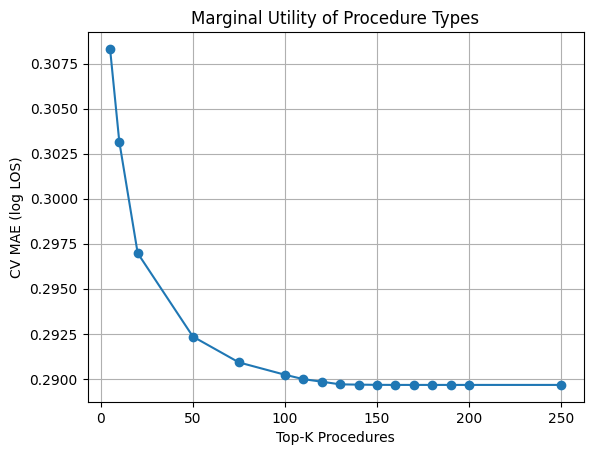

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge


def eval_cv_numeric(X, y, model, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    maes = []
    for tr, te in kf.split(X):
        model.fit(X.iloc[tr], y.iloc[tr])
        pred = model.predict(X.iloc[te])
        maes.append(mean_absolute_error(y.iloc[te], pred))
    return float(np.mean(maes))

def build_presence(df_events, keep_names):
    d = df_events[df_events["canonical_name"].isin(keep_names)][["stay_id", "canonical_name"]].copy()
    d["present"] = 1
    wide = d.pivot_table(
        index="stay_id",
        columns="canonical_name",
        values="present",
        aggfunc="max",
        fill_value=0
    )
    return wide


df = df.copy()
df["los"] = pd.to_numeric(df["los"], errors="coerce")
df["procedure_time_min"] = pd.to_numeric(df["procedure_time_min"], errors="coerce")

df = df.dropna(subset=["stay_id", "los"])
df["log_los"] = np.log1p(df["los"])

stay_n = df["stay_id"].nunique()

cov = (
    df.groupby("canonical_name")["stay_id"]
      .nunique()
      .sort_values(ascending=False)
)

cov = cov.to_frame("n_stays")
cov["coverage"] = cov["n_stays"] / stay_n

print("Total unique procedures:", len(cov))


summary = (
    df.groupby("stay_id")
      .agg(
          proc_events=("canonical_name", "size"),
          proc_unique=("canonical_name", pd.Series.nunique),
          proc_time_sum=("procedure_time_min", "sum"),
          proc_time_mean=("procedure_time_min", "mean"),
          los=("los", "first"),
          log_los=("log_los", "first"),
      )
)

y = summary["log_los"]


Ks = [5, 10, 20, 50, 75 ,100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250]
ridge = Ridge(alpha=2.0)

rows = []

for K in Ks:
    topk = cov.head(K).index

    pres = build_presence(df, topk)

    X = summary.merge(pres, left_index=True, right_index=True, how="left")
    X = X.fillna(0)

    X_model = X.drop(columns=["los", "log_los"])

    mae = eval_cv_numeric(X_model, y, ridge)

    rows.append({
        "K": K,
        "n_features": X_model.shape[1],
        "mae_log": mae
    })

    print(f"K={K:<4} | features={X_model.shape[1]:<4} | MAE={mae:.6f}")

res = pd.DataFrame(rows)

plt.figure()
plt.plot(res["K"], res["mae_log"], marker="o")
plt.xlabel("Top-K Procedures")
plt.ylabel("CV MAE (log LOS)")
plt.title("Marginal Utility of Procedure Types")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

df = procedure.copy()
k = 100

df["canonical_name"] = df["canonical_name"].astype(str)


stay_n = df["stay_id"].nunique()

coverage = (
    df.groupby("canonical_name")["stay_id"]
      .nunique()
      .sort_values(ascending=False)
)

top_k = coverage.head(k).index

print("Selected procedures:", len(top_k))

df_top_k = df[df["canonical_name"].isin(top_k)].copy()

print("Original rows:", len(df))
print("Filtered rows:", len(df_top_k))


print("Unique stays kept:", df_top_k["stay_id"].nunique())
print("Unique procedures kept:", df_top_k["canonical_name"].nunique())

In [ ]:
df_top_k.to_parquet(f'{dir}/{save_file_address}/procedure_top_100.parquet')

### Load Top_100

In [ ]:
procedure = pd.read_parquet(f'{dir}/{save_file_address}/procedure_top_100.parquet')

## Chartevents

### Numeric chart

##### Make

In [ ]:
numeric_chart_events = """
    WITH selected_category AS (
        SELECT
            d.category,
        FROM `physionet-data.mimiciv_3_1_icu.icustays` i
        JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
            ON i.stay_id = ce.stay_id
        JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
            ON ce.itemid = d.itemid
        GROUP BY d.category
        HAVING count(distinct ce.stay_id) >= 1000
    ),

    selected_items AS (
        SELECT
            d.itemid id,
        FROM `physionet-data.mimiciv_3_1_icu.icustays` i
        JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
            ON i.stay_id = ce.stay_id
        JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
            ON ce.itemid = d.itemid
        GROUP BY d.itemid
        HAVING count(distinct ce.stay_id) >= 750
    )



    SELECT
    ce.subject_id,
    ce.hadm_id,
    ce.stay_id,
    d.itemid,
    DATETIME_DIFF(ce.charttime, i.intime, MINUTE) / 60.0 AS hours_since_icu,

    d.label,
    d.category,

    ce.value,
    ce.valuenum,
    ce.valueuom,

    FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce
    JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
        ON ce.itemid = d.itemid AND d.param_type != 'Text' AND d.param_type != 'Checkbox'
    JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
        ON i.stay_id = ce.stay_id

    WHERE ce.charttime >= i.intime
        AND ce.charttime < DATETIME_ADD(i.intime, INTERVAL 24 HOUR)
        --  OR ce.storetime < DATETIME_ADD(i.intime, INTERVAL 24 HOUR))
        AND category IN (SELECT category FROM selected_category)
        AND d.itemid IN (SELECT id FROM selected_items)
        AND  d.param_type != 'Text' AND d.param_type != 'Checkbox'


"""

process_query_in_chunks(numeric_chart_events, save_file_address, 'numeric_chartevents', page_size= 100_000_000)

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43..

In [ ]:
selected_numeric_chart_events = """
    WITH
    selected_items AS (
        SELECT
            d.itemid
        FROM `physionet-data.mimiciv_3_1_icu.icustays` i
        JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
            ON i.stay_id = ce.stay_id
        JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
            ON ce.itemid = d.itemid
        WHERE d.category IN (
            'Respiratory',
            'Hemodynamics',
            'Cardiovascular',
            'Cardiovascular (Pacer Data)',
            'Routine Vital Signs',
            'Dialysis',
            'Neurological',
            'IABP',
            'Pulmonary'
        )
        GROUP BY d.itemid
        HAVING COUNT(DISTINCT ce.stay_id) >= 750
    )

    SELECT
        ce.subject_id,
        ce.hadm_id,
        ce.stay_id,
        ce.itemid,
        DATETIME_DIFF(ce.charttime, i.intime, MINUTE) / 60.0 AS hours_since_icu,

        d.label,
        d.category,

        ce.value,
        ce.valuenum,
        ce.valueuom

    FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce
    JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
        ON ce.itemid = d.itemid
    JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
        ON ce.stay_id = i.stay_id

    WHERE
        d.param_type NOT IN ('Text', 'Checkbox')

        AND ce.charttime >= i.intime
        AND (
            ce.charttime < DATETIME_ADD(i.intime, INTERVAL 24 HOUR)
            OR ce.storetime < DATETIME_ADD(i.intime, INTERVAL 24 HOUR)
        )

        AND d.category IN (
            'Respiratory',
            'Hemodynamics',
            'Cardiovascular',
            'Cardiovascular (Pacer Data)',
            'Routine Vital Signs',
            'Dialysis',
            'Neurological',
            'IABP',
            'Pulmonary'
        )
        AND ce.itemid IN (SELECT itemid FROM selected_items)


"""

process_query_in_chunks(selected_numeric_chart_events, save_file_address, 'numeric_chartevents_filtered', page_size= 100_000_000)

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43..

##### Load


In [ ]:
# numeric_chart_events = pd.read_parquet(f'{dir}/{save_file_address}/numeric_chartevents.parquet')
numeric_chart_events = pd.read_parquet(f'{dir}/{save_file_address}/numeric_chartevents_filtered.parquet')

## Input Events

### Load

In [ ]:
input_events = pd.read_parquet(f'{dir}/{save_file_address}/input_events.parquet')
input_events.drop(columns = ['secondaryordercategoryname']).to_parquet('input.parquet')

### Make

In [ ]:
input_events_query = """
  SELECT
  i.subject_id, i.hadm_id, i.stay_id,
  d.itemid,
  d.label,
  d.category,
      DATETIME_DIFF(ie.starttime, i.intime, MINUTE) / 60.0 AS hours_since_icu,
  amount,
  amountuom,
  rate,
  rateuom,
  ordercategoryname,

  patientweight,
  statusdescription
  FROM `physionet-data.mimiciv_3_1_icu.inputevents` ie
  JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
    ON ie.stay_id = i.stay_id
  JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
    ON ie.itemid = d.itemid
  WHERE ie.starttime >= i.intime
    AND ie.starttime < DATETIME_ADD(i.intime, INTERVAL 24 HOUR)

  """

process_query_in_chunks(input_events_query, save_file_address, 'input_events', page_size= 100_000_000)

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43..

## Output Events

### Load

In [ ]:
output_events = pd.read_parquet(f'{dir}/{save_file_address}/output_events.parquet')

### Make

In [ ]:
output_events_query = """
SELECT
i.subject_id, i.hadm_id, i.stay_id,
 d.itemid,
 d.category,
  TRIM(REGEXP_REPLACE(d.label, r'\s*#\d+', '')) AS label,
  COALESCE(SAFE_CAST(REGEXP_EXTRACT(d.label, r'#(\d+)') AS INT64), 0) AS part,
  SAFE_CAST(REGEXP_CONTAINS(d.label, r'#\d+') AS INT64) AS has_part,
    DATETIME_DIFF(oe.charttime, i.intime, MINUTE) / 60.0 AS hours_since_icu,
value,
valueuom,
abbreviation
FROM `physionet-data.mimiciv_3_1_icu.icustays` i
JOIN `physionet-data.mimiciv_3_1_icu.outputevents` oe

  ON oe.stay_id = i.stay_id
JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
  ON oe.itemid = d.itemid
WHERE oe.charttime >= i.intime
  AND oe.charttime < DATETIME_ADD(i.intime, INTERVAL 24 HOUR)
  AND d.label NOT IN ('Void', 'Pre-Admission')

  """
process_query_in_chunks(output_events_query, save_file_address, 'output_events', page_size= 100_000_000)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2119/3060515415.py:6: SyntaxWarning: invalid escape sequence '\s'
  TRIM(REGEXP_REPLACE(d.label, r'\s*#\d+', '')) AS label,


Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43..

# Node Embedding Preprocess


In [ ]:
!pip install torch_geometric
from torch_geometric.data import HeteroData


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np


import torch
from torch_geometric.data import HeteroData
import torch.nn as nn
import torch.nn.functional as F

from collections import defaultdict

import gc
import os
from tqdm import tqdm


from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dir = '/content/drive/MyDrive/Thesis/Codes/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Functions

In [ ]:
def build_id_map(unique_vals):
    return {val: i for i, val in enumerate(unique_vals)}

def check_columns(cols_to_check, df, ind):
  node_candidates = []
  edge_candidates = []

  for col in cols_to_check:
      uniq_counts = df.groupby(ind)[col].nunique()

      if (uniq_counts <= 1).all():
          node_candidates.append(col)
      else:
          edge_candidates.append(col)

  print(f"Likely NODE features (constant for each {ind}):", node_candidates)
  print("Likely EDGE features (vary across stays):", edge_candidates)

  return node_candidates, edge_candidates

def bool_to_int(df):
  for col in df.columns:
      if df[col].dtype == bool:
        df[col] = df[col].astype(int)

  return df

In [ ]:
def build_pretrained_embeddings(
    df: pd.DataFrame,
    text_col: str = "Building",
    node_id_col: str = "diag_node_id",
    model_name: str = "emilyalsentzer/Bio_ClinicalBERT",
    batch_size: int = 32,
    max_length: int = 128,
    device: str = None,
    projection_dim: int = 64):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    projection_layer = nn.Linear(model.config.hidden_size, projection_dim).to(device)


    unique_df = df[[node_id_col, text_col]].drop_duplicates().reset_index(drop=True)

    embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(unique_df), batch_size), desc=f"Embedding {text_col}"):
            batch_texts = unique_df[text_col].iloc[i:i+batch_size].astype(str).tolist()

            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)

            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            projected_embeddings = projection_layer(cls_embeddings).cpu().numpy()
            embeddings.append(projected_embeddings)

    embeddings = np.vstack(embeddings)

    final_embeddings = dict(zip(unique_df[node_id_col], embeddings))

    return final_embeddings

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from tqdm import tqdm


def build_long_title_embeddings_with_pca(
    df: pd.DataFrame,
    text_col: str = "long_title",
    node_id_col: str = "long_title_id",
    model_name: str = "emilyalsentzer/Bio_ClinicalBERT",
    batch_size: int = 64,
    max_length: int = 32,
    pca_dim: int = 64,
    device: str = None,):

    from sklearn.decomposition import PCA

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"


    unique_df = (
        df[[node_id_col, text_col]]
        .dropna(subset=[node_id_col])
        .drop_duplicates(subset=[node_id_col])
        .reset_index(drop=True)
    )

    unique_df[text_col] = unique_df[text_col].fillna("unknown").astype(str)


    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    all_embeddings = []


    with torch.no_grad():
        for i in tqdm(range(0, len(unique_df), batch_size), desc="BERT embedding"):

            batch_texts = unique_df[text_col].iloc[i:i + batch_size].tolist()

            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)

            outputs = model(**inputs)

            cls = outputs.last_hidden_state[:, 0, :]

            # normalize (خیلی مهم)
            cls = F.normalize(cls, p=2, dim=1)

            cls = torch.nan_to_num(cls, nan=0.0, posinf=0.0, neginf=0.0)

            all_embeddings.append(cls.cpu().numpy())

    X = np.vstack(all_embeddings).astype(np.float32)  # (N, 768)


    pca = PCA(n_components = pca_dim, random_state=42)
    X_reduced = pca.fit_transform(X)  # (N, pca_dim)
    print("explained variance:", pca.explained_variance_ratio_.sum())
    # normalize دوباره بعد PCA
    X_reduced = X_reduced / (np.linalg.norm(X_reduced, axis=1, keepdims=True) + 1e-8)

    assert not np.isnan(X_reduced).any(), "NaN in embeddings"
    assert not np.isinf(X_reduced).any(), "Inf in embeddings"

    explained_var = pca.explained_variance_ratio_.sum()

    print(f"Original dim: {X.shape}")
    print(f"Reduced dim: {X_reduced.shape}")
    print(f"Explained variance: {explained_var:.4f}")

    final_embeddings = dict(
        zip(unique_df[node_id_col].tolist(), X_reduced)
    )

    return final_embeddings, pca

In [ ]:
import re
from collections import defaultdict

def make_feature_name(feature_names):
  group_indices = defaultdict(list)

  for idx, feat in enumerate(feature_names):
      base = re.split(r"_emb\d+|_ont\d+|_\d+$", feat)[0]
      group_indices[base].append(idx)

  feature_ranges = {k: [v[0], v[-1]] for k, v in group_indices.items()}

  return feature_ranges

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm


def build_embeddings(
    df: pd.DataFrame,
    text_col: str = "long_title",
    node_id_col: str = "long_title_id",
    model_name: str = "emilyalsentzer/Bio_ClinicalBERT",
    batch_size: int = 64,
    max_length: int = 32,
    device: str = None,
):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"


    unique_df = (
        df[[node_id_col, text_col]]
        .dropna(subset=[node_id_col])
        .drop_duplicates(subset=[node_id_col])
        .reset_index(drop=True)
    )

    unique_df[text_col] = unique_df[text_col].fillna("unknown").astype(str)


    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    all_embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(unique_df), batch_size), desc="BERT embedding"):

            batch_texts = unique_df[text_col].iloc[i:i + batch_size].tolist()

            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)

            outputs = model(**inputs)

            cls = outputs.last_hidden_state[:, 0, :]

            cls = F.normalize(cls, p=2, dim=1)

            cls = torch.nan_to_num(cls, nan=0.0, posinf=0.0, neginf=0.0)

            all_embeddings.append(cls.cpu().numpy())

    X = np.vstack(all_embeddings).astype(np.float32)

    assert not np.isnan(X).any()
    assert not np.isinf(X).any()

    id_list = unique_df[node_id_col].tolist()

    return X, id_list

In [ ]:
from sklearn.decomposition import PCA
import numpy as np


def apply_pca_to_embeddings(
    X: np.ndarray,
    id_list: list,
    pca_dim: int = None,
    target_variance: float = None,
    normalize: bool = True,
):


    assert (pca_dim is not None) or (target_variance is not None), \
        "either pca_dim or target_variance must be set"


    if target_variance is not None:
        pca_full = PCA().fit(X)
        cum_var = np.cumsum(pca_full.explained_variance_ratio_)
        pca_dim = np.searchsorted(cum_var, target_variance) + 1

        print(f"[Auto PCA] target_var={target_variance} → dim={pca_dim}")

    pca = PCA(n_components=pca_dim, random_state=42)
    X_reduced = pca.fit_transform(X)

    explained_var = pca.explained_variance_ratio_.sum()

    if normalize:
        X_reduced = X_reduced / (np.linalg.norm(X_reduced, axis=1, keepdims=True) + 1e-8)

    assert not np.isnan(X_reduced).any()
    assert not np.isinf(X_reduced).any()

    print(f"Original dim: {X.shape}")
    print(f"Reduced dim: {X_reduced.shape}")
    print(f"Explained variance: {explained_var:.4f}")

    final_embeddings = dict(zip(id_list, X_reduced))

    return final_embeddings, pca

## Stays Node

In [ ]:
icu_stay_details = pd.read_parquet(f'{dir}/{save_file_address}/icu_stay_selected_score.parquet')

In [ ]:
icu_stay_details = icu_stay_details[(icu_stay_details['los']<=140)]
icu_stay_details = bool_to_int(icu_stay_details)
stay_id_map = build_id_map(icu_stay_details['stay_id'].unique())

In [ ]:
icu_stay_details = icu_stay_details.fillna(0)

In [ ]:
import json

stay_id_map_serializable = {str(int(k)): v for k, v in stay_id_map.items()}

with open(f'{dir}/{save_file_address}/stay_id_map_140.json', 'w') as f:
    json.dump(stay_id_map_serializable, f)

In [ ]:
icu_stay_details['stay_id_mapped'] = icu_stay_details['stay_id'].map(stay_id_map)

### Categorical One Hotted

In [ ]:
unit_map = {
    # Medical / Mixed ICU
    "Medical Intensive Care Unit (MICU)": "Medical / Mixed ICU",
    "Medical/Surgical Intensive Care Unit (MICU/SICU)": "Medical / Mixed ICU",
    "Intensive Care Unit (ICU)": "Medical / Mixed ICU",

    # Surgical / Trauma ICU
    "Surgical Intensive Care Unit (SICU)": "Surgical / Trauma ICU",
    "Trauma SICU (TSICU)": "Surgical / Trauma ICU",
    "Surgery/Trauma": "Surgical / Trauma ICU",

    # Cardiac ICU
    "Cardiac Vascular Intensive Care Unit (CVICU)": "Cardiac ICU",
    "Coronary Care Unit (CCU)": "Cardiac ICU",
    "Medicine/Cardiology Intermediate": "Cardiac ICU",

    # Neuro Critical Care
    "Neuro Surgical Intensive Care Unit (Neuro SICU)": "Neuro Critical Care",
    "Neuro Intermediate": "Neuro Critical Care",
    "Neuro Stepdown": "Neuro Critical Care",

    # Intermediate / Recovery Units
    "Surgery/Vascular/Intermediate": "Intermediate / Recovery Units",
    "PACU": "Intermediate / Recovery Units",
    "Medicine": "Intermediate / Recovery Units",
    "Med/Surg": "Intermediate / Recovery Units"
}
icu_stay_details['icu_careunit'] = icu_stay_details['icu_careunit'].map(unit_map)


admission_type_map = {
    "EW EMER.": "Emergency",
    "DIRECT EMER.": "Emergency",
    "URGENT": "Urgent",
    "OBSERVATION ADMIT": "Observation",
    "EU OBSERVATION": "Observation",
    "DIRECT OBSERVATION": "Observation",
    "AMBULATORY OBSERVATION": "Observation",
    "ELECTIVE": "Elective",
    "SURGICAL SAME DAY ADMISSION": "Surgical / Planned Procedure"
}
icu_stay_details["hosp_admission_type"] = icu_stay_details["hosp_admission_type"].map(admission_type_map).fillna("Other")


admission_location_map = {
    # Emergency origin
    "EMERGENCY ROOM": "Emergency Department",

    # Transfers (external institutions)
    "TRANSFER FROM HOSPITAL": "External Transfer",
    "TRANSFER FROM SKILLED NURSING FACILITY": "External Transfer",
    "AMBULATORY SURGERY TRANSFER": "External Transfer",

    # Referral sources
    "PHYSICIAN REFERRAL": "Referral",
    "CLINIC REFERRAL": "Referral",

    # Self-presented
    "WALK-IN/SELF REFERRAL": "Self / Walk-in",

    # Procedural / Perioperative
    "PROCEDURE SITE": "Procedure / Perioperative",
    "PACU": "Procedure / Perioperative",

    # Special / Administrative
    "INTERNAL TRANSFER TO OR FROM PSYCH": "Internal Transfer",
    "INFORMATION NOT AVAILABLE": "Unknown"
}
icu_stay_details["hosp_admission_location"] = icu_stay_details["hosp_admission_location"].map(admission_location_map).fillna("Other")

In [ ]:
cat_cols = [
    'icu_careunit',
    'hosp_admission_type',
    'hosp_admission_location'
]

icu_stay_details = pd.get_dummies(
    icu_stay_details,
    columns=cat_cols,
    prefix=cat_cols,
    drop_first=False
)

In [ ]:
icu_stay_details = bool_to_int(icu_stay_details)

### Normilize


In [ ]:
should_normalize = []
for col in icu_stay_details.columns:
  if icu_stay_details[col].nunique() >= 3 and not col.endswith('_id')  and col != 'los':
    should_normalize.append(col)

In [ ]:
for col in should_normalize:
    x = torch.tensor(icu_stay_details[col].values, dtype=torch.float32)
    x = (x - x.mean()) / (x.std() + 1e-8)
    icu_stay_details[col] = x.numpy()

### Add To Data


In [ ]:
data = HeteroData()
data['stay'].x = torch.tensor(icu_stay_details.drop(columns = ['stay_id','subject_id', 'hadm_id', 'stay_id_mapped', 'los']).values ,dtype=torch.float32)
data['stay'].x_names = list(icu_stay_details.drop(columns = ['stay_id', 'subject_id', 'hadm_id', 'stay_id_mapped',  'los']).columns)

data['stay'].id = torch.tensor(icu_stay_details['stay_id_mapped'].values , dtype = torch.long)
data['stay'].stay_id = torch.tensor(icu_stay_details['stay_id'].values,  dtype = torch.long)
data['stay'].y = torch.tensor(icu_stay_details['los'].values, dtype = torch.float32)
data['stay'].log_y = torch.log1p(torch.tensor(icu_stay_details['los'].values, dtype = torch.float32))


## Patient

In [ ]:
patient = pd.read_parquet(f'{dir}/{save_file_address}/patient.parquet')
patient['gender'] = patient['gender'].map({'F': 1, 'M':0})
patient_id_map = build_id_map(patient['subject_id'].unique())

In [ ]:
patient = bool_to_int(patient)

In [ ]:
should_normalize=['anchor_age', 'age_score',  'charlson_comorbidity_index']
for col in should_normalize:
    x = torch.tensor(patient[col].values, dtype=torch.float32)
    x = (x - x.mean()) / (x.std() + 1e-8)
    patient[col] = x.numpy()

In [ ]:
patient_id_map = build_id_map(patient['subject_id'].unique())

In [ ]:
data['patient'].x = torch.tensor(patient.drop(columns = ['subject_id', 'hadm_id']).values ,dtype=torch.float32)

In [ ]:
data['patient'].x_names = list(patient.drop(columns = ['subject_id', 'hadm_id']).columns)

## Triage


In [ ]:
triage =  pd.read_parquet(f'{dir}/{save_file_address}/triage.parquet')

In [ ]:
triage = triage.dropna(subset=['chiefcomplaint'])

In [ ]:
import re

def normalize_pain_value(v):
    if v is None:
        return None

    v = str(v).strip().lower()
    v = v.replace('"', '').replace("'", "")
    v = re.sub(r'\s+', ' ', v)
    v = v.replace('/10', '')
    v = v.replace('\\', '-')

    return v

def map_pain(v):

    v = normalize_pain_value(v)

    if v is None or v in {'', '-', '___', '?'}:
        return -2 # Numerical representation for 'not available'

    if v in {'0', '00', '000', 'denies', 'no'}:
        return 0 # Numerical representation for 'none'

    if any(k in v for k in [
        'unable', 'uta', 'uto', 'unresponsive',
        'intubated', 'sedated', 'asleep', 'sleeping',
        'non verbal', 'nonverbal'
    ]):
        return -1 # Numerical representation for 'unable to rate'

    # Ordinal mapping for severity for textual descriptions
    if v in {'mild', 'minimal', 'slight', 'a little', 'little bit', 'not much'}:
        return 1 # 'very low'

    if v in {'moderate'}:
        return 2 # 'middle'

    if v in {'severe', 'very bad', 'critical'}:
        return 3 # 'very high' (for simplicity, using 3 as max for mapped strings)

    if re.match(r'^\d+(\.\d+)?-\d+(\.\d+)?$', v):
        lo, hi = map(float, v.split('-'))
        v = (lo + hi) / 2

    try:
        num = float(v)
        if num > 10 and num <= 100:
          num = num / 10

        # Mapping numerical pain scores to ordinal scale
        if num <= 0:
            return 0  # 'none'
        elif num <= 2:
            return 1  # 'very low'
        elif num <= 4:
            return 2  # 'middle low'
        elif num <= 5.5:
            return 3  # 'middle'
        elif num <= 7:
            return 4  # 'middle high'
        elif num <= 8.5:
            return 5  # 'high'
        else:
            return 6  # 'very high'

    except:
        return -2 # Numerical representation for 'not available'

In [ ]:
triage['pain'] = triage['pain'].apply(map_pain)

In [ ]:
for col in triage.columns:
  if triage[col].isna().sum() != 0:
    triage[f'is_{col}'] = triage[col]
    triage[f'is_{col}'] = triage[f'is_{col}'].isna().astype(int)
    triage[col] = triage[col].fillna(0)

In [ ]:
chiefcomplaint_map = build_id_map(triage['chiefcomplaint'].unique())
triage['chiefcomplaint_id'] = triage['chiefcomplaint'].map(chiefcomplaint_map)

In [ ]:
X, ids = build_embeddings(triage,
    text_col="chiefcomplaint",
    node_id_col="chiefcomplaint_id")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

BERT embedding: 100%|██████████| 130/130 [11:59<00:00,  5.54s/it]


In [ ]:
triage_embeddings, pca = apply_pca_to_embeddings(X, ids, target_variance=0.85)

In [ ]:
torch.manual_seed(42)
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, module='pandas')


embedding_dim = len(next(iter(triage_embeddings.values())))

for i in range(embedding_dim):
    triage[f'chiefcomplaint_emb_{i}'] = np.nan

for chief_id, embedding_vec in triage_embeddings.items():
    mask = triage['chiefcomplaint_id'] == chief_id
    for i, emb_val in enumerate(embedding_vec):
        triage.loc[mask, f'chiefcomplaint_emb_{i}'] = emb_val

for i in range(embedding_dim):
    triage[f'chiefcomplaint_emb_{i}'] = triage[f'chiefcomplaint_emb_{i}'].fillna(0)

In [ ]:
should_normalize=['er_stay', 'pain', 'er_icu_los', 'temperature',
                  'dbp', 'heartrate', 'o2sat',
                  'resprate', 'sbp']

for col in should_normalize:
    x = torch.tensor(triage[col].values, dtype=torch.float32)
    x = (x - x.mean()) / (x.std() + 1e-8)
    triage[col] = x.numpy()

In [ ]:
triage = triage.merge(icu_stay_details[['subject_id',	'stay_id']],
                      on = ['subject_id', 'stay_id'],
                      how = 'right')

In [ ]:
triage = triage.fillna(0)

In [ ]:
triage['stay_id_mapped'] = triage['stay_id'].map(stay_id_map)

In [ ]:
triage['subject_id_mapped'] = triage['subject_id'].map(patient_id_map)

In [ ]:
src =  torch.tensor(triage['subject_id_mapped'].values, dtype=torch.long)
dst =  torch.tensor(triage['stay_id_mapped'].values , dtype=torch.long)

edge_index = torch.stack([src, dst])
data[('patient', 'HAS_STAY', 'stay')].edge_index = edge_index
data[('patient', 'HAS_STAY', 'stay')].edge_attr = torch.tensor(triage.drop(columns=['subject_id', 'hadm_id', 'stay_id',
                                                                                    'stay_id_mapped', 'subject_id_mapped',
                                                                                    'chiefcomplaint'
                                                                                    ]).values,  dtype=torch.float32)

data[('patient', 'HAS_STAY', 'stay')].attr_names = list(triage.drop(columns=['subject_id', 'hadm_id', 'stay_id',
                                                                                    'stay_id_mapped', 'subject_id_mapped',
                                                                                    'chiefcomplaint'
                                                                                    ]).columns)

In [ ]:
save_data_address = f'Graph_Correct'
os.makedirs(f'{dir}/{save_data_address}')


In [ ]:
torch.save(data, f'{dir}/{save_data_address}/data.pt')

## Diagnoses

In [ ]:
data = torch.load(f'{dir}/data.pt', weights_only=False)
stay_id = np.array(data['stay'].stay_id)
stay_id_map = build_id_map(stay_id)

In [ ]:
diagnoses = pd.read_parquet(f'{dir}/{save_file_address}/diagnoses.parquet')
diagnoses = diagnoses[diagnoses['seq_num'] <= 10]
diagnoses = diagnoses[diagnoses['stay_id'].isin(stay_id)]

In [ ]:
def categorize_icd_code(icd_code, icd_version):

    categories = {}
    categories['diag_id'] = (icd_code, icd_version)


    if icd_code is None or pd.isna(icd_code):
        icd_code = "UNK"

    if icd_version is None or pd.isna(icd_version):
        icd_version = 9
    icd_code = str(icd_code).strip()

    if icd_version == 9:
        if len(icd_code) >= 3:
            major_cat = icd_code[:3]
        else:
            major_cat = icd_code

        if major_cat.startswith(('001', '002', '003', '004', '005', '006', '007', '008', '009')):
            categories['major_category'] = 'infectious_diseases'
        elif major_cat.startswith(('140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199')):
            categories['major_category'] = 'neoplasms'
        elif major_cat.startswith(('240', '241', '242', '243', '244', '245', '246', '247', '248', '249', '250', '251', '252', '253', '254', '255', '256', '257', '258', '259')):
            categories['major_category'] = 'endocrine_nutritional_metabolic'
        elif major_cat.startswith(('280', '281', '282', '283', '284', '285', '286', '287', '288', '289')):
            categories['major_category'] = 'blood_diseases'
        elif major_cat.startswith(('290', '291', '292', '293', '294', '295', '296', '297', '298', '299', '300', '301', '302', '303', '304', '305', '306', '307', '308', '309', '310', '311', '312', '313', '314', '315', '316', '317', '318', '319')):
            categories['major_category'] = 'mental_disorders'
        elif major_cat.startswith(('320', '321', '322', '323', '324', '325', '326', '327', '328', '329', '330', '331', '332', '333', '334', '335', '336', '337', '338', '339', '340', '341', '342', '343', '344', '345', '346', '347', '348', '349', '350', '351', '352', '353', '354', '355', '356', '357', '358', '359')):
            categories['major_category'] = 'nervous_system'
        elif major_cat.startswith(('360', '361', '362', '363', '364', '365', '366', '367', '368', '369', '370', '371', '372', '373', '374', '375', '376', '377', '378', '379')):
            categories['major_category'] = 'eye_diseases'
        elif major_cat.startswith(('380', '381', '382', '383', '384', '385', '386', '387', '388', '389', '390', '391', '392', '393', '394', '395', '396', '397', '398', '399')):
            categories['major_category'] = 'ear_diseases'
        elif major_cat.startswith(('401', '402', '403', '404', '405', '406', '407', '408', '409', '410', '411', '412', '413', '414', '415', '416', '417', '418', '419', '420', '421', '422', '423', '424', '425', '426', '427', '428', '429', '430', '431', '432', '433', '434', '435', '436', '437', '438', '439', '440', '441', '442', '443', '444', '445', '446', '447', '448', '449', '450', '451', '452', '453', '454', '455', '456', '457', '458', '459')):
            categories['major_category'] = 'circulatory_system'
        elif major_cat.startswith(('460', '461', '462', '463', '464', '465', '466', '467', '468', '469', '470', '471', '472', '473', '474', '475', '476', '477', '478', '479', '480', '481', '482', '483', '484', '485', '486', '487', '488', '489', '490', '491', '492', '493', '494', '495', '496', '497', '498', '499', '500', '501', '502', '503', '504', '505', '506', '507', '508', '509', '510', '511', '512', '513', '514', '515', '516', '517', '518', '519')):
            categories['major_category'] = 'respiratory_system'
        elif major_cat.startswith(('520', '521', '522', '523', '524', '525', '526', '527', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538', '539', '540', '541', '542', '543', '544', '545', '546', '547', '548', '549', '550', '551', '552', '553', '554', '555', '556', '557', '558', '559', '560', '561', '562', '563', '564', '565', '566', '567', '568', '569', '570', '571', '572', '573', '574', '575', '576', '577', '578', '579')):
            categories['major_category'] = 'digestive_system'
        elif major_cat.startswith(('580', '581', '582', '583', '584', '585', '586', '587', '588', '589', '590', '591', '592', '593', '594', '595', '596', '597', '598', '599')):
            categories['major_category'] = 'genitourinary_system'
        elif major_cat.startswith(('600', '601', '602', '603', '604', '605', '606', '607', '608', '609', '610', '611', '612', '613', '614', '615', '616', '617', '618', '619', '620', '621', '622', '623', '624', '625', '626', '627', '628', '629')):
            categories['major_category'] = 'pregnancy_childbirth_puerperium'
        elif major_cat.startswith(('630', '631', '632', '633', '634', '635', '636', '637', '638', '639', '640', '641', '642', '643', '644', '645', '646', '647', '648', '649', '650', '651', '652', '653', '654', '655', '656', '657', '658', '659', '660', '661', '662', '663', '664', '665', '666', '667', '668', '669', '670', '671', '672', '673', '674', '675', '676', '677', '678', '679')):
            categories['major_category'] = 'perinatal_conditions'
        elif major_cat.startswith(('680', '681', '682', '683', '684', '685', '686', '687', '688', '689', '690', '691', '692', '693', '694', '695', '696', '697', '698', '699', '700', '701', '702', '703', '704', '705', '706', '707', '708', '709', '710', '711', '712', '713', '714', '715', '716', '717', '718', '719', '720', '721', '722', '723', '724', '725', '726', '727', '728', '729', '730', '731', '732', '733', '734', '735', '736', '737', '738', '739')):
            categories['major_category'] = 'skin_subcutaneous_tissue'
        elif major_cat.startswith(('740', '741', '742', '743', '744', '745', '746', '747', '748', '749', '750', '751', '752', '753', '754', '755', '756', '757', '758', '759')):
            categories['major_category'] = 'congenital_anomalies'
        elif major_cat.startswith(('760', '761', '762', '763', '764', '765', '766', '767', '768', '769', '770', '771', '772', '773', '774', '775', '776', '777', '778', '779', '780', '781', '782', '783', '784', '785', '786', '787', '788', '789', '790', '791', '792', '793', '794', '795', '796', '797', '798', '799')):
            categories['major_category'] = 'symptoms_signs_ill_defined'
        elif major_cat.startswith(('800', '801', '802', '803', '804', '805', '806', '807', '808', '809', '810', '811', '812', '813', '814', '815', '816', '817', '818', '819', '820', '821', '822', '823', '824', '825', '826', '827', '828', '829', '830', '831', '832', '833', '834', '835', '836', '837', '838', '839', '840', '841', '842', '843', '844', '845', '846', '847', '848', '849', '850', '851', '852', '853', '854', '855', '856', '857', '858', '859', '860', '861', '862', '863', '864', '865', '866', '867', '868', '869', '870', '871', '872', '873', '874', '875', '876', '877', '878', '879', '880', '881', '882', '883', '884', '885', '886', '887', '888', '889', '890', '891', '892', '893', '894', '895', '896', '897', '898', '899', '900', '901', '902', '903', '904', '905', '906', '907', '908', '909', '910', '911', '912', '913', '914', '915', '916', '917', '918', '919', '920', '921', '922', '923', '924', '925', '926', '927', '928', '929', '930', '931', '932', '933', '934', '935', '936', '937', '938', '939', '940', '941', '942', '943', '944', '945', '946', '947', '948', '949', '950', '951', '952', '953', '954', '955', '956', '957', '958', '959', '960', '961', '962', '963', '964', '965', '966', '967', '968', '969', '970', '971', '972', '973', '974', '975', '976', '977', '978', '979', '980', '981', '982', '983', '984', '985', '986', '987', '988', '989', '990', '991', '992', '993', '994', '995', '996', '997', '998', '999')):
            categories['major_category'] = 'injury_poisoning'
        elif icd_code.startswith(('V', 'E')):
            categories['major_category'] = 'supplementary_classification'
        else:
            categories['major_category'] = 'other'

        if len(icd_code) >= 4:
            sub_cat = icd_code[:4]
        else:
            sub_cat = icd_code
        categories['subcategory'] = sub_cat

    elif icd_version == 10:
        if len(icd_code) >= 1:
            major_cat = icd_code[0]
        else:
            major_cat = icd_code

        if major_cat in ['A', 'B']:
            categories['major_category'] = 'infectious_diseases'
        elif major_cat in ['C', 'D']:
            categories['major_category'] = 'neoplasms'
        elif major_cat in ['E']:
            categories['major_category'] = 'endocrine_nutritional_metabolic'
        elif major_cat in ['F']:
            categories['major_category'] = 'mental_disorders'
        elif major_cat in ['G']:
            categories['major_category'] = 'nervous_system'
        elif major_cat in ['H']:
            categories['major_category'] = 'eye_ear_diseases'
        elif major_cat in ['I']:
            categories['major_category'] = 'circulatory_system'
        elif major_cat in ['J']:
            categories['major_category'] = 'respiratory_system'
        elif major_cat in ['K']:
            categories['major_category'] = 'digestive_system'
        elif major_cat in ['L']:
            categories['major_category'] = 'skin_subcutaneous_tissue'
        elif major_cat in ['M']:
            categories['major_category'] = 'musculoskeletal_connective_tissue'
        elif major_cat in ['N']:
            categories['major_category'] = 'genitourinary_system'
        elif major_cat in ['O']:
            categories['major_category'] = 'pregnancy_childbirth_puerperium'
        elif major_cat in ['P']:
            categories['major_category'] = 'perinatal_conditions'
        elif major_cat in ['Q']:
            categories['major_category'] = 'congenital_anomalies'
        elif major_cat in ['R']:
            categories['major_category'] = 'symptoms_signs_ill_defined'
        elif major_cat in ['S', 'T']:
            categories['major_category'] = 'injury_poisoning'
        elif major_cat in ['Z']:
            categories['major_category'] = 'health_services_contact'
        elif major_cat in ['V', 'W', 'X', 'Y']:
            categories['major_category'] = 'external_causes'
        else:
            categories['major_category'] = 'other'

        if len(icd_code) >= 3:
            sub_cat = icd_code[:3]
        else:
            sub_cat = icd_code
        categories['subcategory'] = sub_cat

    categories['icd_version'] = icd_version
    categories['code_length'] = len(icd_code)

    return categories

In [ ]:
diagnoses['major_category'] = diagnoses.apply(lambda x: categorize_icd_code(x['icd_code'], x['icd_version'])['major_category'], axis=1)
diagnoses['subcategory'] = diagnoses.apply(lambda x: categorize_icd_code(x['icd_code'], x['icd_version'])['subcategory'], axis=1)

subcategory_map = build_id_map(diagnoses['subcategory'].unique())
diagnoses['subcategory_id'] = diagnoses['subcategory'].map(subcategory_map)

diagnoses_map = build_id_map(diagnoses['long_title'].unique())
diagnoses['long_title_id'] = diagnoses['long_title'].map(diagnoses_map)

diagnoses_map = build_id_map(diagnoses['major_category'].unique())
diagnoses['major_category_id'] = diagnoses['major_category'].map(diagnoses_map)

In [ ]:
X, ids = build_embeddings(diagnoses,
    text_col="major_category",
    node_id_col="major_category_id",)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT embedding: 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]


In [ ]:
diagnoses_embeddings, pca = apply_pca_to_embeddings(X, ids, pca_dim=16)

Original dim: (24, 768)
Reduced dim: (24, 16)
Explained variance: 0.9346


In [ ]:
embedding_dim = len(next(iter(diagnoses_embeddings.values())))

for i in range(embedding_dim):
    diagnoses[f'major_category_emb_{i}'] = np.nan

for category_id, embedding_vec in diagnoses_embeddings.items():
    mask = diagnoses['major_category_id'] == category_id
    for i, emb_val in enumerate(embedding_vec):
        diagnoses.loc[mask, f'major_category_emb_{i}'] = emb_val


for i in range(embedding_dim):
    diagnoses[f'major_category_emb_{i}'] = diagnoses[f'major_category_emb_{i}'].fillna(0)

diagnoses['icd_version'] = diagnoses['icd_version'].map({9: 0, 10: 1})
diagnoses = bool_to_int(diagnoses)

In [ ]:
diagnoses_nodes = diagnoses[['subcategory_id','icd_version',
                  'major_category_emb_0', 'major_category_emb_1', 'major_category_emb_2',
       'major_category_emb_3', 'major_category_emb_4', 'major_category_emb_5',
       'major_category_emb_6', 'major_category_emb_7', 'major_category_emb_8',
       'major_category_emb_9', 'major_category_emb_10',
       'major_category_emb_11', 'major_category_emb_12',
       'major_category_emb_13', 'major_category_emb_14',
       'major_category_emb_15']]

diagnoses_nodes = diagnoses_nodes.drop_duplicates()

In [ ]:
data['diagnosis'].x = torch.tensor(diagnoses_nodes.drop(columns = ['subcategory_id']).values, dtype=torch.float32)
data['diagnosis'].x_names = list(diagnoses_nodes.drop(columns = ['subcategory_id']).columns)

In [ ]:
long_title_map = build_id_map(diagnoses['long_title'].unique())
diagnoses['long_title_id'] = diagnoses['long_title'].map(long_title_map)

In [ ]:
X, ids = build_embeddings(diagnoses,
    text_col="long_title",
    node_id_col="long_title_id",
    batch_size=128)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT embedding: 100%|██████████| 110/110 [24:14<00:00, 13.22s/it]


In [ ]:
long_title_emb_dict, pca = apply_pca_to_embeddings(X, ids, target_variance=0.85)

[Auto PCA] target_var=0.85 → dim=64
Original dim: (14028, 768)
Reduced dim: (14028, 64)
Explained variance: 0.8512


In [ ]:
embedding_dim = len(next(iter(long_title_emb_dict.values())))

for i in range(embedding_dim):
    diagnoses[f'long_title_emb_{i}'] = np.nan

for title_id, embedding_vec in long_title_emb_dict.items():
    mask = diagnoses['long_title_id'] == title_id
    for i, emb_val in enumerate(embedding_vec):
        diagnoses.loc[mask, f'long_title_emb_{i}'] = emb_val


for i in range(embedding_dim):
    diagnoses[f'long_title_emb_{i}'] = diagnoses[f'long_title_emb_{i}'].fillna(0)

In [ ]:
x = torch.tensor(diagnoses['seq_num'].values, dtype=torch.float32)
x = (x - x.mean()) / (x.std() + 1e-8)
diagnoses['seq_num'] = x.numpy()


In [ ]:
diagnoses['stay_id_mapped'] = diagnoses['stay_id'].map(stay_id_map)

In [ ]:
diagnoses_edges = diagnoses[['subcategory_id', 'seq_num', 'long_title_emb_0', 'long_title_emb_1',
       'long_title_emb_2', 'long_title_emb_3', 'long_title_emb_4',
       'long_title_emb_5', 'long_title_emb_6', 'long_title_emb_7',
       'long_title_emb_8', 'long_title_emb_9', 'long_title_emb_10',
       'long_title_emb_11', 'long_title_emb_12', 'long_title_emb_13',
       'long_title_emb_14', 'long_title_emb_15', 'long_title_emb_16',
       'long_title_emb_17', 'long_title_emb_18', 'long_title_emb_19',
       'long_title_emb_20', 'long_title_emb_21', 'long_title_emb_22',
       'long_title_emb_23', 'long_title_emb_24', 'long_title_emb_25',
       'long_title_emb_26', 'long_title_emb_27', 'long_title_emb_28',
       'long_title_emb_29', 'long_title_emb_30', 'long_title_emb_31',
       'long_title_emb_32', 'long_title_emb_33', 'long_title_emb_34',
       'long_title_emb_35', 'long_title_emb_36', 'long_title_emb_37',
       'long_title_emb_38', 'long_title_emb_39', 'long_title_emb_40',
       'long_title_emb_41', 'long_title_emb_42', 'long_title_emb_43',
       'long_title_emb_44', 'long_title_emb_45', 'long_title_emb_46',
       'long_title_emb_47', 'long_title_emb_48', 'long_title_emb_49',
       'long_title_emb_50', 'long_title_emb_51', 'long_title_emb_52',
       'long_title_emb_53', 'long_title_emb_54', 'long_title_emb_55',
       'long_title_emb_56', 'long_title_emb_57', 'long_title_emb_58',
       'long_title_emb_59', 'long_title_emb_60', 'long_title_emb_61',
       'long_title_emb_62', 'long_title_emb_63', 'stay_id_mapped']]

In [ ]:
data[('stay', 'HAS_DIAGNOSIS', 'diagnosis')].edge_attr = torch.tensor(diagnoses_edges.drop(columns= ['subcategory_id', 'stay_id_mapped']).values, dtype=torch.float32)
data[('stay', 'HAS_DIAGNOSIS', 'diagnosis')].attr_names = list(diagnoses_edges.drop(columns= ['subcategory_id', 'stay_id_mapped']).columns)

In [ ]:
src = torch.tensor(diagnoses['stay_id_mapped'].values, dtype=torch.long)
dst = torch.tensor(diagnoses['subcategory_id'].values, dtype=torch.long)
edge_index = torch.stack([src, dst])

data['stay', 'HAS_DIAGNOSIS', 'diagnosis'].edge_index = edge_index


In [ ]:
torch.save(data, f'{dir}/data.pt')

## Procuders

In [ ]:
procedure = pd.read_parquet(f'{dir}/{save_file_address}/procedure_top_100.parquet')
procedure = procedure[procedure['stay_id'].isin(stay_id)]
procedure.nunique()

,0
stay_id,83068
itemid,111
ordercategoryname,13
procedure_category,12
procedure_label,111
canonical_name,110
procedure_time_min,18151
hours_since_icu,1441
storetime,365643
unitname,1


In [ ]:
procedure = procedure[['stay_id', 'itemid', 'procedure_category',
       'canonical_name', 'hours_since_icu', 'value', 'valueuom',
       'locationcategory', 'statusdescription']]
procedure['locationcategory'] = procedure['locationcategory'].fillna('None')

In [ ]:
import pandas as pd
import numpy as np

def aggregate_procedures(
    df,
    window_hours=24,
    count_cap=20,
    use_value=False,
    is_open = False):

    df = df.copy()
    if is_open:
      df = df[df['hours_since_icu'] <= window_hours]
    else:
      df = df[df['hours_since_icu'] < window_hours]

    df['hours_since_icu'] = df['hours_since_icu'].astype(float)

    agg = df.groupby(['stay_id', 'canonical_name']).agg(

        procedure_category=('procedure_category', 'first'),

        event_count=('hours_since_icu', 'size'),
        unique_hour_count=('hours_since_icu', 'nunique'),

        first_time=('hours_since_icu', 'min'),
        last_time=('hours_since_icu', 'max'),

        unique_locations=('locationcategory', 'nunique'),
        unique_status=('statusdescription', 'nunique'),

        value_mean=('value', 'mean'),
        value_max=('value', 'max'),
        value_min=('value', 'min'),

    ).reset_index()

    agg['time_span'] = agg['last_time'] - agg['first_time']

    agg['event_count'] = agg['event_count'].clip(upper=count_cap)
    agg['unique_hour_count'] = agg['unique_hour_count'].clip(upper=count_cap)


    agg['log_event_count'] = np.log1p(agg['event_count'])
    agg['log_unique_hour_count'] = np.log1p(agg['unique_hour_count'])


    bins = [0, 1, 3, 6, 12, window_hours]
    labels = ['0_1h', '1_3h', '3_6h', '6_12h', '12_24h']

    agg['first_time_bin'] = pd.cut(
        agg['first_time'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    agg['time_span_bin'] = pd.cut(
        agg['time_span'],
        bins=[0, 0.5, 2, 6, 12, window_hours],
        labels=['very_short', 'short', 'medium', 'long', 'very_long'],
        include_lowest=True
    )


    if not use_value:
        agg = agg.drop(columns=[
            'value_mean', 'value_max', 'value_min'
        ])
    else:
        for col in ['value_mean', 'value_max', 'value_min']:
            agg[col] = agg[col].replace([np.inf, -np.inf], np.nan)
            agg[col] = agg[col].fillna(0)

    return agg

In [ ]:
agg = aggregate_procedures(procedure,     window_hours=24)

cat_cols = [
    'procedure_category',
    'first_time_bin',
    'time_span_bin'
]

agg = pd.get_dummies(
    agg,
    columns=cat_cols,
    prefix=cat_cols,
    drop_first=False
)

agg = bool_to_int(agg)

procedure_agg = agg
procedure_map = build_id_map(procedure_agg['canonical_name'].unique())
procedure_agg['canonical_id'] = procedure_agg['canonical_name'].map(procedure_map)

In [ ]:
X, ids = build_embeddings(    procedure_agg,
    text_col="canonical_name",
    node_id_col="canonical_id",
    batch_size=128)


procedure_embeddings, pca = apply_pca_to_embeddings(X, ids, pca_dim=32)


Original dim: (100, 768)
Reduced dim: (100, 32)
Explained variance: 0.8762


In [ ]:
embedding_dim = len(next(iter(procedure_embeddings.values())))

for i in range(embedding_dim):
    procedure_agg[f'canonical_name_emb_{i}'] = np.nan

for canonical_id, embedding_vec in procedure_embeddings.items():
    mask = procedure_agg['canonical_id'] == canonical_id
    for i, emb_val in enumerate(embedding_vec):
        procedure_agg.loc[mask, f'canonical_name_emb_{i}'] = emb_val


for i in range(embedding_dim):
    procedure_agg[f'canonical_name_emb_{i}'] = procedure_agg[f'canonical_name_emb_{i}'].fillna(0)


In [ ]:
procedure_nodes = procedure_agg[['procedure_category_Access Lines - Invasive',
  'procedure_category_Access Lines - Peripheral',
  'procedure_category_Communication',
  'procedure_category_Cultures',
  'procedure_category_Dialysis',
  'procedure_category_GI/GU',
  'procedure_category_Imaging',
  'procedure_category_Intubation/Extubation',
  'procedure_category_Medications',
  'procedure_category_Procedures',
  'procedure_category_Significant Events',
  'procedure_category_Ventilation',
  'canonical_name_emb_0',
       'canonical_name_emb_1', 'canonical_name_emb_2', 'canonical_name_emb_3',
       'canonical_name_emb_4', 'canonical_name_emb_5', 'canonical_name_emb_6',
       'canonical_name_emb_7', 'canonical_name_emb_8', 'canonical_name_emb_9',
       'canonical_name_emb_10', 'canonical_name_emb_11',
       'canonical_name_emb_12', 'canonical_name_emb_13',
       'canonical_name_emb_14', 'canonical_name_emb_15', 'canonical_name_emb_16',
       'canonical_name_emb_17', 'canonical_name_emb_18', 'canonical_name_emb_19',
       'canonical_name_emb_20', 'canonical_name_emb_21', 'canonical_name_emb_22',
       'canonical_name_emb_23', 'canonical_name_emb_24', 'canonical_name_emb_25',
       'canonical_name_emb_26', 'canonical_name_emb_27',
       'canonical_name_emb_28', 'canonical_name_emb_29',
       'canonical_name_emb_30', 'canonical_name_emb_31',
                                 ]].drop_duplicates()

len(procedure_nodes)

100

In [ ]:
data['procedure'].x = torch.tensor(procedure_nodes.values, dtype=torch.float32)
data['procedure'].x_names = list(procedure_nodes.columns)

In [ ]:
procedure_edge = procedure_agg[[
  'stay_id',
  'canonical_id',
  'event_count',
  'unique_hour_count',
  'first_time',
  'last_time',
  'unique_locations',
  'unique_status',
  'time_span',
  'log_event_count',
  'log_unique_hour_count',
  'first_time_bin_0_1h',
  'first_time_bin_1_3h',
  'first_time_bin_3_6h',
  'first_time_bin_6_12h',
  'first_time_bin_12_24h',
  'time_span_bin_very_short',
  'time_span_bin_short',
  'time_span_bin_medium',
  'time_span_bin_long',
  'time_span_bin_very_long']]

In [ ]:
procedure_edge['stay_id_map'] = procedure_edge['stay_id'].map(stay_id_map)

In [ ]:
should_normalize = ['event_count', 'unique_hour_count',
       'first_time', 'last_time', 'unique_locations', 'unique_status',
       'time_span', 'log_event_count', 'log_unique_hour_count']

for col in should_normalize:
  x = torch.tensor(procedure_edge[col].values, dtype=torch.float32)
  x = (x - x.mean()) / (x.std() + 1e-8)
  procedure_edge[col] = x.numpy()

In [ ]:
procedure_edge.columns

Index(['stay_id', 'canonical_id', 'event_count', 'unique_hour_count',
       'first_time', 'last_time', 'unique_locations', 'unique_status',
       'time_span', 'log_event_count', 'log_unique_hour_count',
       'first_time_bin_0_1h', 'first_time_bin_1_3h', 'first_time_bin_3_6h',
       'first_time_bin_6_12h', 'first_time_bin_12_24h',
       'time_span_bin_very_short', 'time_span_bin_short',
       'time_span_bin_medium', 'time_span_bin_long', 'time_span_bin_very_long',
       'stay_id_map'],
      dtype='object')

In [ ]:
data[('stay', 'HAS_PROCEDURE', 'procedure')].edge_attr = torch.tensor(procedure_edge.drop(columns= ['stay_id', 'canonical_id', 'stay_id_map']).values,   dtype=torch.float32)

In [ ]:
src = torch.tensor(procedure_edge['stay_id_map'].values, dtype=torch.long)
dst = torch.tensor(procedure_edge['canonical_id'].values, dtype=torch.long)
edge_index = torch.stack([src, dst])

data[('stay', 'HAS_PROCEDURE', 'procedure')].edge_index = edge_index

In [ ]:
data[('stay', 'HAS_PROCEDURE', 'procedure')].attr_names = list(procedure_edge.drop(columns= ['stay_id', 'canonical_id', 'stay_id_map']).columns)

In [ ]:
torch.save(data, f'{dir}/data.pt')

## Numeric Charts


In [ ]:
import polars as pl

lf = pl.scan_parquet(f'{dir}/{save_file_address}/numeric_chartevents_filtered.parquet')

In [ ]:
gc.collect()

4664

In [ ]:
max_hour = 24
lf = (
    lf
    .filter(pl.col("stay_id").is_in(stay_id))
    .filter((pl.col("hours_since_icu") >= 0) & (pl.col("hours_since_icu") < max_hour))
    .with_columns([
        pl.col("valuenum").cast(pl.Float32),
        pl.col("hours_since_icu").floor().cast(pl.Int32).alias("hour")
    ])
    .select([
        "stay_id", "itemid", "label", "category",
        "hour", "valuenum"
    ])
    .drop_nulls()
)

In [ ]:
qs = (
    lf
    .group_by("itemid")
    .agg([
        pl.col("valuenum").quantile(0.001).alias("qlo"),
        pl.col("valuenum").quantile(0.999).alias("qhi"),
    ])
)

lf = (
    lf.join(qs, on="itemid")
    .with_columns(
        pl.col("valuenum").clip(pl.col("qlo"), pl.col("qhi"))
    )
    .drop(["qlo", "qhi"])
)

In [ ]:
lf_hourly = (
    lf
    .group_by(["stay_id", "itemid", "hour"])
    .agg([
        pl.col("valuenum").median().alias("value")
    ])
)

In [ ]:
agg = (
    lf_hourly
    .group_by(["stay_id", "itemid"])
    .agg([
        pl.col("hour").min().alias("first_time"),
        pl.col("hour").max().alias("last_time"),
        (pl.col("hour").max() - pl.col("hour").min()).alias("time_span"),
        pl.col("hour").n_unique().alias("active_hours"),

        pl.len().alias("event_count"),

        pl.col("value").mean().alias("mean"),
        pl.col("value").std().alias("std"),
        pl.col("value").min().alias("min"),
        pl.col("value").max().alias("max"),
        pl.col("value").last().alias("last"),

        (
            (pl.col("value").last() - pl.col("value").first()) / max_hour
        ).alias("slope"),

        pl.col("value").std().alias("vol"),

        (1 / (pl.col("value").std() + 1e-6)).alias("stab"),
    ])
)

In [ ]:
agg = agg.with_columns(
    (max_hour - pl.col("last_time")).alias("recency")
)
agg = agg.with_columns(
    (pl.col("active_hours") / max_hour).alias("obs_rate")
)

In [ ]:
item_nodes = (
    lf
    .select(["itemid", "label", "category"])
    .unique()
)

item_nodes_df = item_nodes.collect()

In [ ]:
item_nodes_df = item_nodes_df.to_pandas()

In [ ]:
chart_node_map = build_id_map(item_nodes_df['label'].unique())
chart_category_map = build_id_map(item_nodes_df['category'].unique())
item_nodes_df['itemid'] = item_nodes_df['label'].map(chart_node_map)
item_nodes_df['category_id'] = item_nodes_df['category'].map(chart_category_map)

In [ ]:
import torch
torch.manual_seed(42)

chart_label_embeddings,  pca_model = build_long_title_embeddings_with_pca(
    item_nodes_df,
    text_col="label",
    node_id_col="itemid",
    batch_size=128,
    pca_dim=32,
)



embedding_dim = len(next(iter(chart_label_embeddings.values())))

for i in range(embedding_dim):
    item_nodes_df[f'concept_emb_{i}'] = np.nan

for concept_id, embedding_vec in chart_label_embeddings.items():
    mask = item_nodes_df['itemid'] == concept_id
    for i, emb_val in enumerate(embedding_vec):
        item_nodes_df.loc[mask, f'concept_emb_{i}'] = emb_val


for i in range(embedding_dim):
    item_nodes_df[f'concept_emb_{i}'] = item_nodes_df[f'concept_emb_{i}'].fillna(0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT embedding: 100%|██████████| 1/1 [00:10<00:00, 10.53s/it]


explained variance: 0.8502697
Original dim: (125, 768)
Reduced dim: (125, 32)
Explained variance: 0.8503


In [ ]:
import torch
torch.manual_seed(42)

chart_label_embeddings,  pca_model = build_long_title_embeddings_with_pca(
    item_nodes_df,
    text_col="category",
    node_id_col="category_id",
    batch_size=128,
    pca_dim=4,
)



embedding_dim = len(next(iter(chart_label_embeddings.values())))

for i in range(embedding_dim):
    item_nodes_df[f'category_emb_{i}'] = np.nan

for concept_id, embedding_vec in chart_label_embeddings.items():
    mask = item_nodes_df['itemid'] == concept_id
    for i, emb_val in enumerate(embedding_vec):
        item_nodes_df.loc[mask, f'category_emb_{i}'] = emb_val


for i in range(embedding_dim):
    item_nodes_df[f'category_emb_{i}'] = item_nodes_df[f'category_emb_{i}'].fillna(0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT embedding: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]

explained variance: 0.9263537
Original dim: (6, 768)
Reduced dim: (6, 4)
Explained variance: 0.9264


In [ ]:
data['chart_numeric'].x = torch.tensor(item_nodes_df.drop(columns = ['itemid', 'label',
                                                                   'category', 'category_id']).values, dtype = torch.float32)

data['chart_numeric'].x_names = list(item_nodes_df.drop(columns = ['itemid', 'label',
                                                                   'category', 'category_id']).columns)

In [ ]:
del pca_model, item_nodes_df
gc.collect()

79

In [ ]:
edge_df = agg.collect()

In [ ]:
edge_df = (
    edge_df
    .with_columns([
        pl.col("std").fill_null(0.0),
        pl.col("vol").fill_null(0.0),
    ])
    .with_columns([
        (1 / (pl.col("vol") + 1e-6)).alias("stab"),
        (pl.col("recency") / max_hour).alias("recency"),
        (pl.col("active_hours") / max_hour).alias("obs_rate"),
        (pl.col("event_count") / (pl.col("time_span") + 1)).alias("density"),
    ])
)

In [ ]:
edge_df = edge_df.to_pandas()

In [ ]:
chart_node_map = build_id_map(edge_df['itemid'].unique())
edge_df['itemid'] = edge_df['itemid'].map(chart_node_map)


In [ ]:
should_normalize= ['first_time', 'last_time', 'time_span',
       'active_hours', 'event_count', 'mean', 'std', 'min', 'max', 'last',
       'slope', 'vol', 'stab', 'recency', 'obs_rate', 'density']
for col in should_normalize:
  x = torch.tensor(edge_df[col].values, dtype=torch.float32)
  x = (x - x.mean()) / (x.std() + 1e-8)
  edge_df[col] = x.numpy()


In [ ]:
data[('stay', 'HAS_CHARTED', 'chart_numeric')].edge_attr = torch.tensor(edge_df.drop(columns = ['stay_id',
                                                                                      'itemid']).values, dtype = torch.float32)

data[('stay', 'HAS_CHARTED', 'chart_numeric')].attr_names = list(edge_df.drop(columns = ['stay_id',
                                                                                      'itemid']).columns)

In [ ]:
edge_df['stay_id_mapped'] = edge_df['stay_id'].map(stay_id_map)
src = torch.tensor(edge_df['stay_id_mapped'].values, dtype = torch.long)
dst = torch.tensor(edge_df['itemid'].values, dtype = torch.long)

data[('stay', 'HAS_CHARTED', 'chart_numeric')].edge_index = torch.stack([src, dst])

In [ ]:
torch.save(data, f'{dir}/data.pt')

## Input

In [ ]:
input_events = pd.read_parquet(f'{dir}/{save_file_address}/input_events.parquet')
input_events = input_events[input_events['stay_id'].isin(np.array(stay_id))]

In [ ]:
def clean_input_events(input_events, window_hours=24, is_open = False):
    df = input_events.copy()

    df = df[df["hours_since_icu"].notna()]
    if is_open:
      df = df[(df["hours_since_icu"] >= 0) & (df["hours_since_icu"] <= window_hours)]
    else:
      df = df[(df["hours_since_icu"] >= 0) & (df["hours_since_icu"] < window_hours)]

    df["hours_since_icu"] = pd.to_numeric(df["hours_since_icu"], errors="coerce")
    df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

    for col in ["label", "amountuom", "ordercategoryname", "statusdescription"]:
        df[col] = df[col].fillna("Unknown").astype(str)

    df = df[df["stay_id"].notna()]
    df = df[df["label"].notna()]

    df.loc[df["amount"] < 0, "amount"] = np.nan

    return df

def canonicalize_input_label(df):
    df = df.copy()

    df["input_name"] = (
        df["label"]
        .astype(str)
        .str.replace(r"\s*\(.*?\)", "", regex=True)
        .str.strip()
        .str.lower()
    )

    return df

In [ ]:
import re
import numpy as np
import pandas as pd

def normalize_input_name(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s*\(.*?\)", "", x)
    x = re.sub(r"\s+", " ", x)
    x = x.replace(".", "")
    return x


def map_input_category(name):
    name = normalize_input_name(name)

    if any(k in name for k in [
        "phenylephrine", "norepinephrine", "epinephrine", "vasopressin",
        "dopamine", "dobutamine", "milrinone", "angiotensin ii",
        "isuprel", "epoprostenol", "treprostinil"
    ]):
        return "vasopressor_inotrope"

    if any(k in name for k in [
        "propofol", "dexmedetomidine", "midazolam", "lorazepam",
        "diazepam", "ketamine", "pentobarbital"
    ]):
        return "sedative_anesthetic"

    if any(k in name for k in [
        "fentanyl", "morphine", "hydromorphone", "methadone",
        "meperidine", "ketorolac", "acetaminophen"
    ]):
        return "analgesic"

    if any(k in name for k in [
        "vancomycin", "azithromycin", "acyclovir", "linezolid",
        "metronidazole", "ciprofloxacin", "levofloxacin", "bactrim",
        "keflex", "ampicillin", "cefazolin", "fluconazole",
        "clindamycin", "cefepime", "meropenem", "aztreonam",
        "ceftazidime", "piperacillin", "daptomycin",
        "piperacillin/tazobactam", "moxifloxacin", "ceftriaxone",
        "gentamicin", "tobramycin", "doxycycline",
        "imipenem/cilastatin", "nafcillin", "colistin", "ambisome",
        "caspofungin", "amikacin", "gancyclovir", "ethambutol",
        "tigecycline", "ertapenem", "ceftaroline", "isoniazid",
        "rifampin", "valgancyclovir", "voriconazole", "micafungin",
        "tamiflu", "foscarnet"
    ]):
        return "antiinfective"

    if any(k in name for k in [
        "insulin", "dextrose", "glucose"
    ]):
        return "glucose_insulin"

    if any(k in name for k in [
        "calcium", "magnesium", "potassium", "kcl", "k phos",
        "na phos", "sodium bicarbonate", "sodium acetate",
        "nacl 3%", "nacl 23.4%", "phosphate"
    ]):
        return "electrolyte_acidbase"

    if any(k in name for k in [
        "free water", "lr", "nacl 0.9", "nacl 0.45",
        "d5", "sterile water", "solution", "piggyback",
        "crystalloid", "colloid", "albumin", "hetastarch"
    ]):
        return "fluid"

    if any(k in name for k in [
        "packed red blood cells", "packed rbc", "platelets",
        "fresh frozen plasma", "ffp", "cryoprecipitate",
        "cell saver", "autologous blood", "factor viia",
        "factor viii", "profilnine"
    ]):
        return "blood_product"

    if any(k in name for k in [
        "heparin", "enoxaparin", "coumadin", "warfarin",
        "argatroban", "bivalirudin", "eptifibatide",
        "tirofiban", "abciximab", "fondaparinux",
        "lepirudin", "citrate", "acd-a citrate", "aminocaproic acid",
        "protamine"
    ]):
        return "anticoagulation_hemostasis"

    if any(k in name for k in [
        "nicardipine", "diltiazem", "labetalol", "metoprolol",
        "hydralazine", "nitroprusside", "nitroglycerin",
        "amiodarone", "esmolol", "verapamil", "adenosine",
        "digoxin", "procainamide", "clevidipine"
    ]):
        return "cardiovascular"

    if any(k in name for k in [
        "furosemide", "bumetanide", "mannitol"
    ]):
        return "diuretic_osmotic"

    if any(k in name for k in [
        "rocuronium", "vecuronium", "cisatracurium",
        "neostigmine", "glycopyrolate"
    ]):
        return "neuromuscular"

    if any(k in name for k in [
        "pantoprazole", "omeprazole", "esomeprazole",
        "famotidine", "ranitidine", "lansoprazole",
        "carafate", "gastric meds", "ondansetron",
        "octreotide"
    ]):
        return "gastrointestinal"

    if any(k in name for k in [
        "dilantin", "fosphenytoin", "levetiracetam"
    ]):
        return "antiepileptic"

    if any(k in name for k in [
        "tpn", "lipids", "amino acids", "parenteral nutrition",
        "two cal", "pulmocare", "glucerna", "vivonex", "isosource",
        "nutren", "ensure", "impact", "peptamen", "jevity",
        "vital", "promote", "nepro", "osmolite", "beneprotein",
        "boost", "replete", "probalance", "optisource",
        "mighty shake", "scandi shake", "enlive", "fiber supplement"
    ]):
        return "nutrition"

    if any(k in name for k in [
        "folic acid", "thiamine", "multivitamins", "vitamin k"
    ]):
        return "vitamin_supplement"

    if any(k in name for k in [
        "atropine", "naloxone", "alteplase", "iv immune globulin",
        "mycophenolate", "cyclosporine", "acetylcysteine",
        "pamidronate", "drotrecogin"
    ]):
        return "other_specific_medication"

    if any(k in name for k in [
        "or ", "pacu", "cath lab", "pre-admission", "po intake",
        "gt flush"
    ]):
        return "intake_context"
    if any(k in name for k in [
        "free water", "lr", "lactated ringer",
        "nacl", "saline",
        "d5", "dextrose",
        "sterile water",
        "crystalloid", "colloid",
        "albumin", "hetastarch"
    ]):
        return "fluid"

    # saline variations
    if "nacl" in name or "saline" in name:
        return "fluid"

    # haloperidol (مهم)
    if "haloperidol" in name:
        return "antipsychotic"

    # lidocaine (مهم)
    if "lidocaine" in name:
        return "antiarrhythmic_local_anesthetic"

    # fibersource / novasource
    if any(k in name for k in ["fibersource", "novasource"]):
        return "nutrition"

    # plasma pheresis
    if "plasma pheresis" in name:
        return "blood_procedure"

    # dextran
    if "dextran" in name:
        return "colloid_fluid"

    # erythromycin (antibiotic)
    if "erythromycin" in name:
        return "antiinfective"

    # hydrochloric acid
    if "hydrochloric acid" in name:
        return "acid_base"

    # nesiritide
    if "nesiritide" in name:
        return "cardiovascular"

    return "other"

In [ ]:
input_df = clean_input_events(input_events, window_hours=24)
input_df = canonicalize_input_label(input_df)

In [ ]:
def add_input_concepts(df, use_concept_node=False):
    df = df.copy()

    df["input_concept"] = df["input_name"].apply(map_input_category)

    # اگر بخوای nodeها خیلی کم و abstract باشند:
    if use_concept_node:
        df["input_node_name"] = df["input_concept"]
    else:

        df["input_node_name"] = df["input_concept"] + " | " + df["input_name"]

    return df

input_df = add_input_concepts(input_df)


In [ ]:
import numpy as np
import pandas as pd

def build_input_node_features(df, max_hours=24, is_open = False):

    df = df.copy()

    if is_open:
      df = df[df["hours_since_icu"].between(0, max_hours)]
    else:
      df = df[(df["hours_since_icu"] >= 0) & (df["hours_since_icu"] < max_hours)]

    df["hours_since_icu"] = df["hours_since_icu"].astype(float)

    df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
    df["amount_log"] = np.log1p(df["amount"].clip(lower=0))


    stay_level = (
        df.groupby(["input_node_name", "stay_id"])
        .agg(
            event_count=("amount", "size"),
            mean_hour=("hours_since_icu", "mean"),
        )
        .reset_index()
    )


    total_stays = df["stay_id"].nunique()

    global_stats = (
        df.groupby("input_node_name")
        .agg(
            total_event_count=("amount", "size"),
            unique_stay_count=("stay_id", "nunique"),

            mean_hour=("hours_since_icu", "mean"),
            std_hour=("hours_since_icu", "std"),

            global_mean=("amount", "mean"),
            global_std=("amount", "std"),
            global_max=("amount", "max"),

            log_mean=("amount_log", "mean"),
        )
        .reset_index()
    )


    stay_dist = (
        stay_level.groupby("input_node_name")
        .agg(
            avg_events_per_stay=("event_count", "mean"),
            std_events_per_stay=("event_count", "std"),
        )
        .reset_index()
    )


    feat = global_stats.merge(stay_dist, on="input_node_name", how="left")


    feat["prevalence"] = feat["unique_stay_count"] / total_stays

    feat["coefficient_of_variation"] = (
        feat["global_std"] / (feat["global_mean"] + 1e-6)
    )

    df["early"] = (df["hours_since_icu"] < 6).astype(int)
    df["late"] = (df["hours_since_icu"] >= 12).astype(int)

    temporal = (
        df.groupby("input_node_name")
        .agg(
            early_rate=("early", "mean"),
            late_rate=("late", "mean"),
        )
        .reset_index()
    )

    feat = feat.merge(temporal, on="input_node_name", how="left")

    feat = feat.fillna(0)

    feature_cols = [
        "prevalence",
        "avg_events_per_stay",
        "std_events_per_stay",
        "mean_hour",
        "std_hour",
        "early_rate",
        "late_rate",
        "global_mean",
        "global_std",
        "global_max",
        "log_mean",
        "coefficient_of_variation",
    ]

    X = feat[feature_cols].values.astype(np.float32)

    return feat, X, feature_cols

In [ ]:
input_node = input_df[[ 'input_name', 'input_concept', 'input_node_name']].drop_duplicates()

In [ ]:
input_node, _, _ = build_input_node_features(input_df, max_hours=24)

In [ ]:
input_id_map = build_id_map(input_node['input_node_name'].unique())
input_node['node_id'] = input_node['input_node_name'].map(input_id_map)

In [ ]:
should_normalize = ['total_event_count', 'unique_stay_count',
       'mean_hour', 'std_hour', 'global_mean', 'global_std', 'global_max',
       'log_mean', 'avg_events_per_stay', 'std_events_per_stay', 'prevalence',
       'coefficient_of_variation', 'early_rate', 'late_rate']
for col in should_normalize:
  x = torch.tensor(input_node[col].values, dtype=torch.float32)
  x = (x - x.mean()) / (x.std() + 1e-8)
  input_node[col] = x.numpy()


In [ ]:
import torch
torch.manual_seed(42)

input_node_embeddings,  pca_model = build_long_title_embeddings_with_pca(
    input_node,
    text_col="input_node_name",
    node_id_col="node_id",
    batch_size=128,
    pca_dim=32,
)



embedding_dim = len(next(iter(input_node_embeddings.values())))

for i in range(embedding_dim):
    input_node[f'concept_emb_{i}'] = np.nan

for concept_id, embedding_vec in input_node_embeddings.items():
    mask = input_node['node_id'] == concept_id
    for i, emb_val in enumerate(embedding_vec):
        input_node.loc[mask, f'concept_emb_{i}'] = emb_val


for i in range(embedding_dim):
    input_node[f'concept_emb_{i}'] = input_node[f'concept_emb_{i}'].fillna(0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT embedding: 100%|██████████| 2/2 [00:14<00:00,  7.28s/it]


explained variance: 0.8842836
Original dim: (256, 768)
Reduced dim: (256, 32)
Explained variance: 0.8843


In [ ]:
def build_hourly_input_events(df, max_h = 24):
    df = df.copy()

    df["hour_bin"] = np.floor(df["hours_since_icu"]).astype(int)
    df["hour_bin"] = df["hour_bin"].clip(0, max_h)

    # drip یا bolus
    df["is_drip"] = (
        df["ordercategoryname"]
        .str.lower()
        .str.contains("drip", na=False)
        .astype(int)
    )

    df["is_bolus"] = (
        df["ordercategoryname"]
        .str.lower()
        .str.contains("bolus", na=False)
        .astype(int)
    )

    df["is_change_rate"] = (
        df["statusdescription"]
        .str.lower()
        .str.contains("change", na=False)
        .astype(int)
    )

    df["amount_log"] = np.log1p(df["amount"].fillna(0))

    hourly = (
        df
        .groupby(["stay_id", "input_node_name", "hour_bin"])
        .agg(
            amount_sum=("amount_log", "sum"),
            amount_mean=("amount_log", "mean"),
            event_count=("amount_log", "size"),
            is_drip=("is_drip", "max"),
            is_bolus=("is_bolus", "max"),
            change_rate_count=("is_change_rate", "sum"),
        )
        .reset_index()
    )

    return hourly

In [ ]:
def aggregate_input_edges(hourly, max_h = 24):
    hourly = hourly.copy()

    agg = (
        hourly
        .groupby(["stay_id", "input_node_name"])
        .agg(
            total_amount=("amount_sum", "sum"),
            mean_amount=("amount_mean", "mean"),
            max_amount=("amount_sum", "max"),
            std_amount=("amount_sum", "std"),

            event_count=("event_count", "sum"),
            active_hours=("hour_bin", "nunique"),

            first_time=("hour_bin", "min"),
            last_time=("hour_bin", "max"),

            is_drip=("is_drip", "max"),
            is_bolus=("is_bolus", "max"),
            change_rate_count=("change_rate_count", "sum"),
        )
        .reset_index()
    )

    agg["std_amount"] = agg["std_amount"].fillna(0)

    agg["time_span"] = agg["last_time"] - agg["first_time"]

    agg["dose_density"] = agg["active_hours"] / (agg["time_span"] + 1.0)

    agg["dose_instability"] = agg["std_amount"] / (agg["mean_amount"] + 1e-6)

    agg["first_time_norm"] = agg["first_time"] / max_h
    agg["last_time_norm"] = agg["last_time"] / max_h

    return agg

In [ ]:
hourly = build_hourly_input_events(input_df,max_h = 24)
agg  = aggregate_input_edges(hourly, max_h = 24)

In [ ]:
agg['input_node_id'] = agg['input_node_name'].map(input_id_map)

In [ ]:
agg.columns

Index(['stay_id', 'input_node_name', 'total_amount', 'mean_amount',
       'max_amount', 'std_amount', 'event_count', 'active_hours', 'first_time',
       'last_time', 'is_drip', 'is_bolus', 'change_rate_count', 'time_span',
       'dose_density', 'dose_instability', 'first_time_norm', 'last_time_norm',
       'input_node_id'],
      dtype='object')

In [ ]:
should_normalize = ['total_amount', 'mean_amount',
       'max_amount', 'std_amount', 'event_count', 'active_hours', 'first_time',
       'last_time', 'is_drip', 'is_bolus', 'change_rate_count', 'time_span',
       'dose_density', 'dose_instability', 'first_time_norm', 'last_time_norm']
for col in should_normalize:
  x = torch.tensor(agg[col].values, dtype=torch.float32)
  x = (x - x.mean()) / (x.std() + 1e-8)
  agg[col] = x.numpy()

In [ ]:
agg['stay_id_mapped'] = agg['stay_id'].map(stay_id_map)

In [ ]:
src = torch.tensor(agg['stay_id_mapped'].values, dtype=torch.long)
dst = torch.tensor(agg['input_node_id'].values , dtype=torch.long)


data[('stay', 'HAS_INPUT', 'input')].edge_attr = torch.tensor(agg.drop(columns = ['stay_id', 'stay_id_mapped','input_node_name', 'input_node_id']).values, dtype=torch.float32)
data[('stay', 'HAS_INPUT', 'input')].attr_names = list(agg.drop(columns = ['stay_id', 'stay_id_mapped','input_node_name', 'input_node_id']).columns)


data[('stay', 'HAS_INPUT', 'input')].edge_index = torch.stack([src, dst])

## Output



In [ ]:
output_events = pd.read_parquet(f'{dir}/{save_file_address}/output_events.parquet')
output_events = output_events[output_events['stay_id'].isin(stay_id)]

In [ ]:
def clean_output_events(df, window_hours= 24, is_open = False):
    df = df.copy()

    df = df[df["hours_since_icu"].notna()]
    if is_open:
      df = df[(df["hours_since_icu"] >= 0) & (df["hours_since_icu"] <= window_hours)]
    else:
      df = df[(df["hours_since_icu"] >= 0) & (df["hours_since_icu"] < window_hours)]

    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["hours_since_icu"] = pd.to_numeric(df["hours_since_icu"], errors="coerce")

    df = df[df["stay_id"].notna()]
    df = df[df["label"].notna()]

    df["value"] = df["value"].clip(lower=0)

    return df
output_events = clean_output_events(output_events)
import re

def normalize_output_name(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s*\#\d+", "", x)
    x = re.sub(r"[^a-z0-9\s]", "", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

output_events["output_name"] = output_events["label"].apply(normalize_output_name)

In [ ]:
def map_output_category(name):
    name = str(name).lower()

    if any(k in name for k in [
        "urine", "foley", "condom cath", "straight cath",
        "suprapubic", "ureteral stent", "nephrostomy"
    ]):
        return "urinary_output"

    if any(k in name for k in [
        "stool", "fecal", "rectal tube", "ostomy output"
    ]):
        return "stool_output"

    if any(k in name for k in [
        "emesis", "vomit"
    ]):
        return "emesis"

    if any(k in name for k in [
        "gastric", "nasogastric", "oral gastric", "sump",
        "anderson", "ewald", "tf residual"
    ]):
        return "gastric_output"


    if any(k in name for k in [
        "chest tube", "pleural", "mediastinal"
    ]):
        return "thoracic_drainage"


    if any(k in name for k in [
        "jackson pratt", "jp", "hemovac", "davol", "penrose"
    ]):
        return "surgical_drain"

    if any(k in name for k in [
        "drainage bag", "pigtail"
    ]):
        return "general_drain"


    if any(k in name for k in [
        "cerebral", "ventricular", "subdural"
    ]):
        return "neuro_drain"


    if "pericardial" in name:
        return "cardiac_drain"


    if any(k in name for k in [
        "ebl"
    ]):
        return "blood_loss"


    if any(k in name for k in [
        "irrigant"
    ]):
        return "irrigation"

    if any(k in name for k in [
        "pacu", "or ", "cath lab"
    ]):
        return "procedure_context_output"

    if any(k in name for k in [
        "ileoconduit", "jejunostomy"
    ]):
        return "surgical_gi_output"

    if any(k in name for k in [
        "blakemore"
    ]):
        return "special_device"

    if "wound vac" in name:
        return "surgical_drain"

    if "lumbar" in name:
        return "neuro_drain"

    if "t tube" in name or "t-tube" in name:
        return "biliary_drain"

    if name.strip() == "tap":
        return "procedural_drain"

    if "red rubber" in name:
        return "urinary_output"

    return "other_output"

In [ ]:
output_events["output_category"] = output_events["output_name"].apply(map_output_category)
output_events["output_node_name"] = output_events["output_category"] + " | " + output_events["output_name"]


In [ ]:
def build_output_node_features(df, max_hours = 24, is_open = False):

    df = df.copy()

    if is_open:
      df = df[df["hours_since_icu"].between(0, max_hours)]
    else:
      df = df[(df["hours_since_icu"] >= 0) & (df["hours_since_icu"] < max_hours)]

    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["value_log"] = np.log1p(df["value"].clip(lower=0))

    stay_level = (
        df.groupby(["output_node_name", "stay_id"])
        .agg(
            event_count=("value", "size"),
            mean_hour=("hours_since_icu", "mean"),
        )
        .reset_index()
    )

    total_stays = df["stay_id"].nunique()

    global_stats = (
        df.groupby("output_node_name")
        .agg(
            total_event_count=("value", "size"),
            unique_stay_count=("stay_id", "nunique"),

            mean_hour=("hours_since_icu", "mean"),
            std_hour=("hours_since_icu", "std"),

            global_mean=("value", "mean"),
            global_std=("value", "std"),
            global_min=("value", "min"),
            global_max=("value", "max"),

            log_mean=("value_log", "mean"),
        )
        .reset_index()
    )

    stay_dist = (
        stay_level.groupby("output_node_name")
        .agg(
            avg_events_per_stay=("event_count", "mean"),
            std_events_per_stay=("event_count", "std"),
        )
        .reset_index()
    )


    feat = global_stats.merge(stay_dist, on="output_node_name", how="left")


    feat["prevalence"] = feat["unique_stay_count"] / total_stays

    feat["coefficient_of_variation"] = (
        feat["global_std"] / (feat["global_mean"] + 1e-6)
    )


    df["early"] = (df["hours_since_icu"] < 6).astype(int)
    df["mid"] = ((df["hours_since_icu"] >= 6) & (df["hours_since_icu"] < 12)).astype(int)
    df["late"] = (df["hours_since_icu"] >= 12).astype(int)

    temporal = (
        df.groupby("output_node_name")
        .agg(
            early_rate=("early", "mean"),
            mid_rate=("mid", "mean"),
            late_rate=("late", "mean"),
        )
        .reset_index()
    )

    feat = feat.merge(temporal, on="output_node_name", how="left")


    obs_rate = (
        df.groupby("output_node_name")["stay_id"]
        .count()
        .reset_index(name="obs_count")
    )

    feat = feat.merge(obs_rate, on="output_node_name", how="left")
    feat["obs_rate"] = feat["obs_count"] / feat["total_event_count"]

    feat = feat.fillna(0)

    feature_cols = [
        "prevalence",
        "avg_events_per_stay",
        "std_events_per_stay",
        "mean_hour",
        "std_hour",
        "early_rate",
        "mid_rate",
        "late_rate",
        "global_mean",
        "global_std",
        "global_min",
        "global_max",
        "log_mean",
        "coefficient_of_variation",
    ]

    X = feat[feature_cols].values.astype(np.float32)

    return feat, X, feature_cols

In [ ]:
output_node, _, _ = build_output_node_features(output_events)
output_id_map = build_id_map(output_events['output_node_name'].unique())
output_node['node_id'] = output_node['output_node_name'].map(output_id_map)

In [ ]:
should_normalize = [ 'total_event_count', 'unique_stay_count',
       'mean_hour', 'std_hour', 'global_mean', 'global_std', 'global_min',
       'global_max', 'log_mean', 'avg_events_per_stay', 'std_events_per_stay',
       'prevalence', 'coefficient_of_variation', 'early_rate', 'mid_rate',
       'late_rate', 'obs_count', 'obs_rate']

for col in should_normalize:
  x = torch.tensor(output_node[col].values, dtype=torch.float32)
  x = (x - x.mean()) / (x.std() + 1e-8)
  output_node[col] = x.numpy()

In [ ]:
import torch
torch.manual_seed(42)

output_node_embeddings,  pca_model = build_long_title_embeddings_with_pca(

    output_node,
    text_col="output_node_name",
    node_id_col="node_id",
    batch_size=128,
    pca_dim=32,
)

embedding_dim = len(next(iter(output_node_embeddings.values())))

for i in range(embedding_dim):
    output_node[f'concept_emb_{i}'] = np.nan

for concept_id, embedding_vec in output_node_embeddings.items():
    mask = output_node['node_id'] == concept_id
    for i, emb_val in enumerate(embedding_vec):
        output_node.loc[mask, f'concept_emb_{i}'] = emb_val


for i in range(embedding_dim):
    output_node[f'concept_emb_{i}'] = output_node[f'concept_emb_{i}'].fillna(0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT embedding: 100%|██████████| 1/1 [00:03<00:00,  3.73s/it]


explained variance: 0.96326566
Original dim: (53, 768)
Reduced dim: (53, 32)
Explained variance: 0.9633


In [ ]:
output_node.columns

Index(['output_node_name', 'total_event_count', 'unique_stay_count',
       'mean_hour', 'std_hour', 'global_mean', 'global_std', 'global_min',
       'global_max', 'log_mean', 'avg_events_per_stay', 'std_events_per_stay',
       'prevalence', 'coefficient_of_variation', 'early_rate', 'mid_rate',
       'late_rate', 'obs_count', 'obs_rate', 'node_id', 'concept_emb_0',
       'concept_emb_1', 'concept_emb_2', 'concept_emb_3', 'concept_emb_4',
       'concept_emb_5', 'concept_emb_6', 'concept_emb_7', 'concept_emb_8',
       'concept_emb_9', 'concept_emb_10', 'concept_emb_11', 'concept_emb_12',
       'concept_emb_13', 'concept_emb_14', 'concept_emb_15', 'concept_emb_16',
       'concept_emb_17', 'concept_emb_18', 'concept_emb_19', 'concept_emb_20',
       'concept_emb_21', 'concept_emb_22', 'concept_emb_23', 'concept_emb_24',
       'concept_emb_25', 'concept_emb_26', 'concept_emb_27', 'concept_emb_28',
       'concept_emb_29', 'concept_emb_30', 'concept_emb_31'],
      dtype='object')

In [ ]:
data['output'].x = torch.tensor(output_node.drop(columns = ['output_node_name', 'node_id']).values,  dtype=torch.float32)
data['output'].x_names = list(output_node.drop(columns = ['output_node_name', 'node_id']).columns)

In [ ]:
def build_hourly_output(df, max_h = 24):
    df = df.copy()

    df["hour_bin"] = np.floor(df["hours_since_icu"]).astype(int)
    df["hour_bin"] = df["hour_bin"].clip(0, max_h)

    df["value_log"] = np.log1p(df["value"])

    hourly = (
        df
        .groupby(["stay_id", "output_node_name", "hour_bin"])
        .agg(
            value_sum=("value_log", "sum"),
            value_mean=("value_log", "mean"),
            event_count=("value_log", "size")
        )
        .reset_index()
    )

    return hourly

In [ ]:
def aggregate_output_edges(hourly, max_h = 24):
    agg = (
        hourly
        .groupby(["stay_id", "output_node_name"])
        .agg(
            total_output=("value_sum", "sum"),
            mean_output=("value_mean", "mean"),
            max_output=("value_sum", "max"),
            std_output=("value_sum", "std"),

            event_count=("event_count", "sum"),
            active_hours=("hour_bin", "nunique"),

            first_time=("hour_bin", "min"),
            last_time=("hour_bin", "max"),
        )
        .reset_index()
    )

    agg["std_output"] = agg["std_output"].fillna(0)

    agg["time_span"] = agg["last_time"] - agg["first_time"]

    agg["output_density"] = agg["active_hours"] / (agg["time_span"] + 1.0)

    agg["output_instability"] = (
        agg["std_output"] / (agg["mean_output"] + 1e-6)
    )

    agg["first_time_norm"] = agg["first_time"] / max_h
    agg["last_time_norm"] = agg["last_time"] / max_h

    return agg

In [ ]:
hourly = build_hourly_output(output_events, 24)
agg = aggregate_output_edges(hourly, 24)

In [ ]:
agg['stay_id_mapped'] = agg['stay_id'].map(stay_id_map)

agg.columns

Index(['stay_id', 'output_node_name', 'total_output', 'mean_output',
       'max_output', 'std_output', 'event_count', 'active_hours', 'first_time',
       'last_time', 'time_span', 'output_density', 'output_instability',
       'first_time_norm', 'last_time_norm', 'stay_id_mapped'],
      dtype='object')

In [ ]:
agg['output_node_name'] = agg['output_node_name'].map(output_id_map)


agg.columns

Index(['stay_id', 'output_node_name', 'total_output', 'mean_output',
       'max_output', 'std_output', 'event_count', 'active_hours', 'first_time',
       'last_time', 'time_span', 'output_density', 'output_instability',
       'first_time_norm', 'last_time_norm', 'stay_id_mapped'],
      dtype='object')

In [ ]:
should_normalize = [ 'total_output', 'mean_output',
       'max_output', 'std_output', 'event_count', 'active_hours', 'first_time',
       'last_time', 'time_span', 'output_density', 'output_instability',
       'first_time_norm', 'last_time_norm']

for col in should_normalize:
  x = torch.tensor(agg[col].values, dtype=torch.float32)
  x = (x - x.mean()) / (x.std() + 1e-8)
  agg[col] = x.numpy()

In [ ]:
src = torch.tensor(agg['stay_id_mapped'].values, dtype=torch.long)
dst = torch.tensor(agg['output_node_name'].values , dtype=torch.long)


data[(('stay', 'HAS_OUTPUT', 'output'))].edge_attr = torch.tensor(agg.drop(columns = ['stay_id', 'stay_id_mapped','output_node_name']).values, dtype=torch.float32)
data[(('stay', 'HAS_OUTPUT', 'output'))].attr_names = list(agg.drop(columns = ['stay_id', 'stay_id_mapped','output_node_name']).columns)

data[(('stay', 'HAS_OUTPUT', 'output'))].edge_index = torch.stack([src, dst])

In [ ]:
torch.save(data, f'{dir}/data.pt')

In [ ]:
print('Checking for NaNs and Infs in node attributes:')
for node_type in data.node_types:
    if hasattr(data[node_type], 'x') and data[node_type].x is not None:
        if torch.isnan(data[node_type].x).any():
            print(f'  Node type {node_type} contains NaNs in its x attribute.')
        elif torch.isinf(data[node_type].x).any():
            print(f'  Node type {node_type} contains Infs in its x attribute.')
        else:
            print(f'  Node type {node_type} is clean (no NaNs or Infs in x attribute).')
    else:
        print(f'  Node type {node_type} has no x attribute or x is None.')

print('\nChecking for NaNs and Infs in edge attributes:')
for edge_type in data.edge_types:
    if hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None:
        if torch.isnan(data[edge_type].edge_attr).any():
            print(f'  Edge type {edge_type} contains NaNs in its edge_attr attribute.')
        elif torch.isinf(data[edge_type].edge_attr).any():
            print(f'  Edge type {edge_type} contains Infs in its edge_attr attribute.')
        else:
            print(f'  Edge type {edge_type} is clean (no NaNs or Infs in edge_attr attribute).')
    else:
        print(f'  Edge type {edge_type} has no edge_attr attribute or edge_attr is None.')

print('\nChecking index ranges for nodes:')
for node_type in data.node_types:
    if hasattr(data[node_type], 'id') and data[node_type].id is not None:
        min_idx = data[node_type].id.min()
        max_idx = data[node_type].id.max()
        num_nodes = len(data[node_type].id)
        print(f'  Node type {node_type}: Min Index = {min_idx}, Max Index = {max_idx}, Num Nodes = {num_nodes}')
    elif hasattr(data[node_type], 'x') and data[node_type].x is not None:
        # Fallback if 'id' attribute is not explicitly set but nodes exist
        num_nodes = data[node_type].x.shape[0]
        print(f'  Node type {node_type}: Node count = {num_nodes} (no explicit ID attribute for range check).')
    else:
        print(f'  Node type {node_type}: No node ID or features found.')

print('\nChecking index ranges for edges:')
for edge_type in data.edge_types:
    if hasattr(data[edge_type], 'edge_index') and data[edge_type].edge_index is not None:
        src, dst = data[edge_type].edge_index
        min_src = src.min()
        max_src = src.max()
        min_dst = dst.min()
        max_dst = dst.max()
        num_edges = data[edge_type].edge_index.shape[1]
        print(f'  Edge type {edge_type}: Num Edges = {num_edges}, Source Index Range = [{min_src}, {max_src}], Destination Index Range = [{min_dst}, {max_dst}]')
    else:
        print(f'  Edge type {edge_type}: No edge_index attribute found.')


print('\nStay ID Map (first 10 entries):')
# Print first 10 entries of stay_id_map for inspection
print(dict(list(stay_id_map.items())[:10]))

# Check min and max values of mapped stay IDs
m_values = list(stay_id_map.values())
if m_values:
    print(f'  Min mapped ID: {min(m_values)}')
    print(f'  Max mapped ID: {max(m_values)}')
else:
    print('  Stay ID Map is empty.')

Checking for NaNs and Infs in node attributes:
  Node type stay is clean (no NaNs or Infs in x attribute).
  Node type patient is clean (no NaNs or Infs in x attribute).
  Node type diagnosis is clean (no NaNs or Infs in x attribute).
  Node type procedure is clean (no NaNs or Infs in x attribute).
  Node type chart_numeric is clean (no NaNs or Infs in x attribute).
  Node type input is clean (no NaNs or Infs in x attribute).
  Node type output is clean (no NaNs or Infs in x attribute).

Checking for NaNs and Infs in edge attributes:
  Edge type ('patient', 'HAS_STAY', 'stay') is clean (no NaNs or Infs in edge_attr attribute).
  Edge type ('stay', 'HAS_DIAGNOSIS', 'diagnosis') is clean (no NaNs or Infs in edge_attr attribute).
  Edge type ('stay', 'HAS_PROCEDURE', 'procedure') is clean (no NaNs or Infs in edge_attr attribute).
  Edge type ('stay', 'HAS_CHARTED', 'chart_numeric') is clean (no NaNs or Infs in edge_attr attribute).
  Edge type ('stay', 'HAS_INPUT', 'input') is clean (no N